In [ ]:
import numpy as np
import pandas as pd
import plotly.graph_objects as go
from lifelines import KaplanMeierFitter

np.random.seed(42)
df = pd.DataFrame({
    "time": np.random.exponential(10, 100),
    "event": np.random.randint(0, 2, 100),
    "group": np.random.choice(["A", "B", "C"], 100)
})

In [ ]:
import numpy as np
import pandas as pd
import plotly.graph_objects as go
from sksurv.nonparametric import kaplan_meier_estimator  # Kaplan-Meier estimation
from lifelines.statistics import logrank_test  # Log-rank test from lifelines

# Sample Data
np.random.seed(42)
df = pd.DataFrame({
    "time": np.random.exponential(10, 100),
    "event": np.random.randint(0, 2, 100),  # 0 or 1 (needs conversion)
    "group": np.random.choice(["A", "B", "C"], 100)
})

# Convert event column to boolean (Required for sksurv)
df["event"] = df["event"].astype(bool)  # ✅ Fix: Convert 0/1 to False/True

# Initialize Plotly figure
fig = go.Figure()

# Kaplan-Meier estimation for each group
for group in df["group"].unique():
    mask = df["group"] == group

    # Get time and event data for the group
    time_points, survival_probs = kaplan_meier_estimator(df["event"][mask], df["time"][mask])

    fig.add_trace(go.Scatter(
        x=time_points,
        y=survival_probs,
        mode="lines",
        name=f"Group {group}"
    ))

# Compute Log-Rank Test for two groups (e.g., A vs. B)
group_A = df[df["group"] == "A"]
group_B = df[df["group"] == "B"]

logrank_result = logrank_test(
    group_A["time"], group_B["time"], event_observed_A=group_A["event"], event_observed_B=group_B["event"]
)

p_value = logrank_result.p_value  # Extract p-value

# Add p-value to the plot title
fig.update_layout(
    title=f"Kaplan-Meier Survival Curves (Log-Rank p={p_value:.4f})",
    xaxis_title="Time",
    yaxis_title="Survival Probability",
    template="plotly_white"
)

fig.show()

print(f"Log-Rank Test p-value: {p_value:.4f}")


In [ ]:
import sksurv
print(sksurv.__version__)

# SVC Probability and kernel studies

## Kernel studies

In [ ]:
import numpy as np
from scipy.spatial.distance import euclidean

X = np.array([1000, 1005, 4000, 5000])


def rbf(gamma, a, b):
    return np.exp(-gamma * euclidean(a, b))



gamma = 0.001
a = [X[0]]
b = [X[1]]
print(rbf(gamma, a, b))
a = [X[0]]
b = [X[2]]
print(rbf(gamma, a, b))
a = [X[0]]
b = [X[3]]
print(rbf(gamma, a, b))

## Conditional probabilities

### Plot Data

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

X = np.array([[0,1], [1, 2], [2, 6.5], [3, 5], [5, 10], [6,8], [10, 10]])
y = np.array([0, 0, 0, 0, 1, 1, 1])

plt.scatter(X[:, 0], X[:, 1], c = y)
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.title('Created Data')

### Learn Linear SVM

In [ ]:
from sklearn.svm import SVC

clf = SVC(probability=True, kernel="linear", decision_function_shape="ovr")
clf.fit(X, y)

### Plot decision boundary

In [ ]:
# Extract the weights (w) and intercept (b)
w = clf.coef_[0]
b = clf.intercept_[0]

# Compute x-values for decision boundary
x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
x_vals = np.linspace(x_min, x_max, 100)

# Compute y-values for the decision boundary
y_vals = -(w[0] * x_vals + b) / w[1]

# Compute margin lines (support vectors)
margin = 1 / np.sqrt(np.sum(w**2))
y_vals_margin_up = y_vals + margin
y_vals_margin_down = y_vals - margin

# Plot dataset
plt.scatter(X[:, 0], X[:, 1], c=y, cmap=plt.cm.coolwarm, edgecolors='k')
plt.scatter(clf.support_vectors_[:, 0], clf.support_vectors_[:, 1], 
            s=100, facecolors='none', edgecolors='k', label="Support Vectors")

# Plot decision boundary and margins
plt.plot(x_vals, y_vals, 'k-', label="Decision Boundary")
plt.plot(x_vals, y_vals_margin_up, 'k--', label="Margin")
plt.plot(x_vals, y_vals_margin_down, 'k--')

plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.legend()
plt.title("clf Decision Boundary with Support Vectors")
plt.show()

### Compare probabilities from predict_proba and probability function from John C. Platt

In [ ]:
sv = clf.support_vectors_
coef_ = clf.coef_
dual_coef = clf.dual_coef_
print("-- Support vectors\n", sv)
print("-- Dual coefficients\n", dual_coef)
print("-- Decision fonction scores\n", decision_fct_scores)
prob_A = clf.probA_
prob_B = clf.probB_

predicted_proba_svm_function = clf.predict_proba(X)
decision_fct_scores = clf.decision_function(X)/coef_

def compute_prob_platt(probA, probB, decision_fct_scores):
    return 1/(1+np.exp(probA * decision_fct_scores + probB))

predicted_proba_platt_function = compute_prob_platt(prob_A, prob_B, decision_fct_scores)
print("-- Proba Platt function\n", predicted_proba_platt_function)
print("-- Proba predict_proba function\n", predicted_proba_svm_function)

### Learn RBF SVM

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.svm import SVC
from sklearn.datasets import make_classification

# Train an SVM with an RBF kernel
svm_rbf = SVC(kernel="rbf", C=1.0, gamma='scale')
svm_rbf.fit(X, y)

# Create a grid to evaluate model
x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 100),
                     np.linspace(y_min, y_max, 100))

# Predict on grid points
Z = svm_rbf.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

# Plot decision boundary and support vectors
plt.contourf(xx, yy, Z, alpha=0.3, cmap=plt.cm.coolwarm)
plt.scatter(X[:, 0], X[:, 1], c=y, cmap=plt.cm.coolwarm, edgecolors='k')
plt.scatter(svm_rbf.support_vectors_[:, 0], svm_rbf.support_vectors_[:, 1], 
            s=100, facecolors='none', edgecolors='k', label="Support Vectors")

plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.legend()
plt.title("SVM Decision Boundary with RBF Kernel")
plt.show()

In [ ]:
import numpy as np
import plotly.graph_objects as go
from sklearn.svm import SVC
from sklearn.datasets import make_classification

# Generate synthetic 3D dataset
X, y = make_classification(n_samples=100, n_features=3, n_classes=2, 
                           n_informative=3, n_redundant=0, random_state=42)

# Train an SVM with RBF kernel
svm_rbf = SVC(kernel="rbf", C=1.0, gamma='scale')
svm_rbf.fit(X, y)

# Define grid for decision boundary
x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
z_min, z_max = X[:, 2].min() - 1, X[:, 2].max() + 1

xx, yy = np.meshgrid(np.linspace(x_min, x_max, 30), 
                     np.linspace(y_min, y_max, 30))

# Compute decision function for grid points
Z = np.array([svm_rbf.decision_function([[x, y, (z_min + z_max) / 2]])[0] 
              for x, y in zip(xx.ravel(), yy.ravel())])
Z = Z.reshape(xx.shape)

# Create 3D plot
fig = go.Figure()

# Add decision boundary surface
fig.add_trace(go.Surface(x=xx, y=yy, z=Z, colorscale="blues", opacity=0.5))

# Add scatter plot for data points
fig.add_trace(go.Scatter3d(x=X[:, 0], y=X[:, 1], z=X[:, 2], 
                           mode='markers', marker=dict(color=y, size=6, colorscale="Portland"), name="Data Points"))

# Add support vectors
fig.add_trace(go.Scatter3d(x=svm_rbf.support_vectors_[:, 0], 
                           y=svm_rbf.support_vectors_[:, 1], 
                           z=svm_rbf.support_vectors_[:, 2], 
                           mode='markers', marker=dict(symbol="circle", size=8, color='black', opacity=0.7),
                           name="Support Vectors"))

# Labels & Title
fig.update_layout(scene=dict(xaxis_title="Feature 1", 
                             yaxis_title="Feature 2", 
                             zaxis_title="Feature 3"),
                  title="3D SVM Decision Boundary (RBF Kernel)")

# Show interactive plot
fig.show()


In [ ]:
predicted_proba_svm_function = clf.predict_proba(X)
decision_fct_scores = clf.decision_function(X)
prob_A = clf.probA_
prob_B = clf.probB_

def compute_prob_platt(probA, probB, decision_fct_scores):
    return 1/(1+np.exp(probA * decision_fct_scores + probB))

predicted_proba_platt_function = compute_prob_platt(prob_A, prob_B, decision_fct_scores)
print("-- Proba Platt function\n", predicted_proba_platt_function)
print("-- Proba predict_proba function\n", predicted_proba_svm_function)

# Learning a linear line

In [ ]:
import numpy as np

# Patient 25
xdata25 = np.array([ 0,   20,   49,  112,  175,  191,  240,  265,  356,  406,  447,  559,
  605,  658,  678,  720,  783,  812,  860,  984, 1070, 1175, 1287, 1399,
 1511, 1644, 1728, 1771, 1938, 2050, 2267, 2358, 2427, 2533, 2652 ,2771, 2876])
ydata25 = np.array([-1.75438596 , -1.75438596,  -1.75438596 , -8.77192982 ,-10.52631579,
 -12.28070175 ,-12.28070175 ,-12.28070175, -12.28070175 ,-10.52631579,
  -8.77192982, -12.28070175 ,-12.28070175, -17.54385965, -17.54385965,
 -17.54385965 ,-19.29824561, -21.05263158, -21.05263158 ,-22.80701754,
 -21.05263158, -15.78947368, -15.78947368 , -8.77192982,  -5.26315789,
  -5.26315789 ,  0    ,       0    ,       8.77192982  ,12.28070175,
   0 ,      0      ,     1.75438596  , 1.75438596,  10.52631579,
  17.54385965  ,26.31578947])

# Synthetic data
time = np.arange(1, 51)  # 50 time steps
# Generate a linear trend with noise
values = 2.5 * time + np.random.normal(0, 10, size=len(time))


In [ ]:
import numpy as np
from scipy.interpolate import interp1d
import matplotlib.pyplot as plt

# Données du patient 25
xdata25 = np.array([0, 20, 49, 112, 175, 191, 240, 265, 356, 406, 447, 559,
                    605, 658, 678, 720, 783, 812, 860, 984, 1070, 1175, 1287, 1399,
                    1511, 1644, 1728, 1771, 1938, 2050, 2267, 2358, 2427, 2533,
                    2652, 2771, 2876])
ydata25 = np.array([-1.75438596, -1.75438596, -1.75438596, -8.77192982, -10.52631579,
                    -12.28070175, -12.28070175, -12.28070175, -12.28070175, -10.52631579,
                    -8.77192982, -12.28070175, -12.28070175, -17.54385965, -17.54385965,
                    -17.54385965, -19.29824561, -21.05263158, -21.05263158, -22.80701754,
                    -21.05263158, -15.78947368, -15.78947368, -8.77192982, -5.26315789,
                    -5.26315789, 0, 0, 8.77192982, 12.28070175, 0, 0, 1.75438596,
                    1.75438596, 10.52631579, 17.54385965, 26.31578947])

# Création de la fonction d'interpolation linéaire
f_linear = interp1d(xdata25, ydata25, kind='linear')

# Génération de points interpolés
x_interp = np.linspace(xdata25[0], xdata25[-1], 20000)  # 500 points entre le min et le max
y_interp = f_linear(x_interp)
print(f_linear(3500))

# Affichage
plt.figure(figsize=(10,5))
plt.plot(xdata25, ydata25, 'o', label='Données originales')
plt.plot(x_interp, y_interp, '-', label='Interpolation linéaire')
plt.xlabel('x')
plt.ylabel('y')
plt.title('Interpolation linéaire pour le Patient 25')
plt.legend()
plt.show()


# Learning Sigmoid

In [1]:
import numpy as np

# Patient 229
xdata229 = np.array([0,  112,  469,  665,  777,  945, 1120, 1225])
ydata229 = np.array([43, 42, 42, 41, 40, 39, 39, 41])

# Patient 811
xdata811 = np.array([ 0  , 5,  51, 167, 426])
ydata811 = np.array([40, 40 ,39 ,38, 36])

# Patient 124
xdata124 = np.array([0   ,96 , 180 , 285,  376 , 481 , 579 , 690 , 777,  866 , 964 ,1041, 1132, 1154])
ydata124 = np.array([45, 42, 43 ,31, 29, 27, 27, 29 ,26, 25, 26, 24 ,18 ,18])

# Patient 829
xdata829 = np.array([ 0,   35,   84 , 216 , 314,  376,  483,  517,  556 , 629,  734,  832,  902,  965
, 1049 ,1119, 1252])
ydata829 = np.array([44 ,46 ,44 ,45 ,45 ,44 ,40, 38, 35, 22, 21 ,17, 19, 16 ,13 ,14 ,10])

# Patient 835
xdata835 = np.array([0   ,82,  189 , 364,  539,  721,  896, 1085, 1239, 1421, 1519 ,1694, 1876, 1967,
 2024 ,2149, 2190, 2330, 2337, 2435, 2533, 2659, 2778])
ydata835 = np.array([45 ,46 ,46 ,38 ,38, 38, 36 ,35, 33 ,34 ,34 ,34 ,31, 28 ,27, 25 ,22, 16 ,16 ,15, 15 ,16 ,12])

# Patient 966
xdata966 = np.array( [0   ,83  ,188  ,265  ,349  ,461 , 566 , 664,  776,  882,  972, 1070, 1160, 1272,
 1331 ,1482, 1573, 1791, 2267])
ydata966 = np.array([38, 37, 32, 30 ,26 ,28 ,25 ,23 ,23 ,17, 19, 18, 18, 20, 18 ,19 ,19 ,19, 21])

# Patient 368
xdata368 = np.array([ 0  ,20 , 83, 161, 251, 260, 279, 310, 364, 462, 477, 490, 539])
ydata368 = np.array([41, 41, 31 ,27 ,26, 27 ,26 ,22 ,23 ,22 ,15 ,13, 12])

# Patient 805
xdata805 = np.array([0  ,56 ,222, 329 ,427 ,510, 650, 762 ,860])
ydata805 = np.array([34 ,33, 27 ,28 ,17 ,17 ,17 ,19 ,16])

# Patient 366
xdata366 = np.array([0, 378, 476, 608, 652, 818])
ydata366 = np.array([37, 39, 35, 34, 36, 33])

# Patient 1657
xdata1657 = np.array([0,  23,  56, 139 ,245, 258])
ydata1657 = np.array([43 ,43 ,43 ,43 ,39 ,37])

# Patient 1112
xdata1112 = np.array([0,   6,  77 ,154, 175, 190])
ydata1112 = np.array([21, 21, 19, 19, 17, 10])

# Patient 596
xdata596 = np.array([ 0,   91,  161,  202 , 300,  545,  664,  790,  909, 1014, 1112, 1182, 1245, 1322,
1413, 1553, 1658, 1749, 1868, 1959, 2092, 2224, 2336])
ydata596 = np.array([42, 37, 38, 39, 38 ,37, 35, 30, 28, 25, 23, 23, 24, 24 ,26, 24, 25, 25, 25, 25, 25, 23, 24])

In [2]:
def sigmoid(x,Z, L, x0, k, b):
    return L / (Z + np.exp(-k * (x - x0))) + b

def sigmoid_v2(x, k):
    return -1 / 1 + np.exp(-k * (x))

def sigmoid_v3(x, b, k, a):
    return (b) / (1 + np.exp((k * x) - a))

def sigmoid_v4(x, b, k, a, c):
    return (b) / (1 + np.exp((k * (x - a)))) + c

def sigmoid_v5(x, k, a, c):
    return (48 / (1 + np.exp((k * (x - a))))) + c

In [3]:
xdata = xdata368
ydata = ydata368

b = 215.03896580826978
k = 0.002139341023151843
a = -1.4688308688959035
error = 86.50858334953048
Solution for x when y = 24: 283.0744191362506


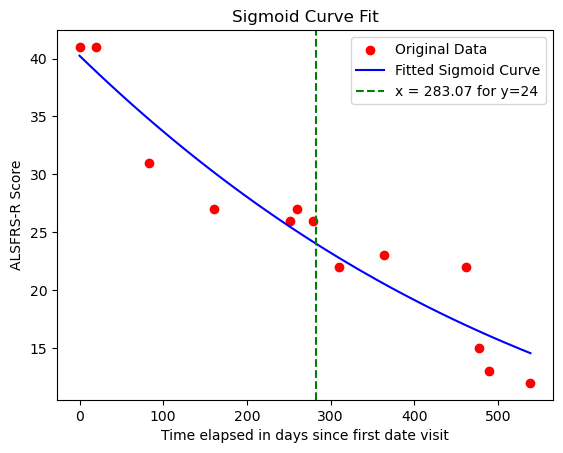

In [4]:
from scipy.optimize import curve_fit
import matplotlib.pyplot as plt

p0 = [48, 0, 0]

lowest_float_value = 2.22e-16
popt, pcov, infodict, i1, i2 = curve_fit(sigmoid_v3,
                       xdata, 
                       ydata,
                       p0=p0, 
                       full_output=True,
                       maxfev=100000)

b, k, a = popt[0], popt[1], popt[2]
print("b =", b)
print("k =", k)
print("a =", a)
print("error =", sum(np.power(infodict["fvec"],2)))

x_fit = np.linspace(min(xdata), max(xdata), 100)
y_fit = sigmoid_v3(x_fit, *popt)

def solve_for_x(b, k, a, y=24):
    x = (np.log((b - y) / y) + a) / k
    return x

x_solution = solve_for_x(*popt, y=24)

print(f"Solution for x when y = 24: {x_solution}")

plt.scatter(xdata, ydata, label="Original Data", color="red")
plt.plot(x_fit, y_fit, label="Fitted Sigmoid Curve", color="blue")

plt.axvline(x_solution, color="green", linestyle="--", label=f"x = {x_solution:.2f} for y=24")

plt.xlabel("Time elapsed in days since first date visit")
plt.ylabel("ALSFRS-R Score")
plt.title("Sigmoid Curve Fit")
plt.legend()
plt.show()

In [ ]:
from scipy.optimize import curve_fit
import matplotlib.pyplot as plt

p0 = [48, 0, 0, 0]

lowest_float_value = 2.22e-16
popt, pcov, infodict, i1, i2 = curve_fit(sigmoid_v4,
                       xdata, 
                       ydata,
                       p0=p0, 
                       full_output=True,
                       maxfev=100000)

b, k, a, c = popt[0], popt[1], popt[2], popt[3]
print("b =", b)
print("k =", k)
print("a =", a)
print("c =", c)
print("error =", sum(np.power(infodict["fvec"],2)))

x_fit = np.linspace(min(xdata), max(xdata), 100)
y_fit = sigmoid_v4(x_fit, *popt)

def solve_for_x(b, k, a, c, y=24):
    term = (b / (y - c)) - 1
    x = (np.log(term) / k) + a
    return x

x_solution = solve_for_x(*popt, y=24)

print(f"Solution for x when y = 24: {x_solution}")

plt.scatter(xdata, ydata, label="Original Data", color="red")
plt.plot(x_fit, y_fit, label="Fitted Sigmoid Curve", color="blue")

plt.axvline(x_solution, color="green", linestyle="--", label=f"x = {x_solution:.2f} for y=24")

plt.xlabel("X")
plt.ylabel("Y")
plt.title("Sigmoid Curve Fit")
plt.legend()
plt.show()

In [ ]:
from scipy.optimize import curve_fit
import matplotlib.pyplot as plt

p0 = [0, 0, 0]

popt, pcov, infodict, i1, i2 = curve_fit(sigmoid_v5,
                       xdata, 
                       ydata,
                       p0=p0, 
                       full_output=True,
                       maxfev=100000000)

k, a, c = popt[0], popt[1], popt[2]
print("k =", b)
print("a =", k)
print("c =", a)
print("error =", sum(np.power(infodict["fvec"],2)))

x_fit = np.linspace(min(xdata), max(xdata), 100)
y_fit = sigmoid_v5(x_fit, *popt)

def solve_for_x(k, a, c, y=24):
    term = (48 / (y - c)) - 1
    x = (np.log(term) / k) + a
    return x

x_solution = solve_for_x(*popt, y=24)

print(f"Solution for x when y = 24: {x_solution}")

plt.scatter(xdata, ydata, label="Original Data", color="red")
plt.plot(x_fit, y_fit, label="Fitted Sigmoid Curve", color="blue")

plt.axvline(x_solution, color="green", linestyle="--", label=f"x = {x_solution:.2f} for y=24")

plt.xlabel("X")
plt.ylabel("Y")
plt.title("Sigmoid Curve Fit")
plt.legend()
plt.show()

In [ ]:
from scipy.optimize import curve_fit
import matplotlib.pyplot as plt

p0 = [48, 0, 0, 0]

lowest_float_value = 2.22e-16
popt, pcov, infodict, i1, i2 = curve_fit(sigmoid_v4,
                       xdata, 
                       ydata,
                       p0=p0,
                       #bounds=((-np.inf, -np.inf, -np.inf, -np.inf),(np.inf, np.inf, np.inf, 23)),
                       bounds=[[0, 0, 0, -48],[48, 10, xdata[-1], 23]],
                       full_output=True,
                       maxfev=100000)

b, k, a, c = popt[0], popt[1], popt[2], popt[3]
print("b =", b)
print("k =", k)
print("a =", a)
print("c =", c)
print("error =", sum(np.power(infodict["fvec"],2)))

x_fit = np.linspace(min(xdata), max(xdata), 100)
y_fit = sigmoid_v4(x_fit, *popt)

def solve_for_x(b, k, a, c, y=24):
    term = (b / (y - c)) - 1
    x = (np.log(term) / k) + a
    return x

x_solution = solve_for_x(*popt, y=24)

print(f"Solution for x when y = 24: {x_solution}")

plt.scatter(xdata, ydata, label="Original Data", color="red")
plt.plot(x_fit, y_fit, label="Fitted Sigmoid Curve", color="blue")

plt.axvline(x_solution, color="green", linestyle="--", label=f"x = {x_solution:.2f} for y=24")

plt.xlabel("X")
plt.ylabel("Y")
plt.title("Sigmoid Curve Fit")
plt.legend()
plt.show()

In [ ]:
np.power([1,2],2)

In [ ]:
from scipy.optimize import curve_fit
import matplotlib.pyplot as plt

p0 = [48, 1.0E-5, 0, 0]

popt, pcov, infodict, i1, i2 = curve_fit(sigmoid_v4,
                       xdata, 
                       ydata,
                       p0=p0,
                       bounds=((38, 0, 0, -10),(48, 10, xdata[-1], 10)),
                       full_output=True,
                       maxfev=10000000)

b, k, a, c = popt[0], popt[1], popt[2], popt[3]
print("b =", b)
print("k =", k)
print("a =", a)
print("c =", c)
print("error =", sum(np.power(infodict["fvec"],2)))

x_fit = np.linspace(min(xdata), max(xdata), 100)
y_fit = sigmoid_v4(x_fit, *popt)

def solve_for_x(b, k, a, c, y=24):
    term = (b / (y - c)) - 1
    x = (np.log(term) / k) + a
    return x

x_solution = solve_for_x(*popt, y=24)
y_one_year = sigmoid_v4(365, *popt)
print(y_one_year)

print(f"Value of D50 when y = 24: {x_solution}")

plt.scatter(xdata, ydata, label="Original data", color="red")
plt.plot(x_fit, y_fit, label="Sigmoid curve", color="blue")

#plt.axvline(x_solution, color="yellow", linestyle="--", label=f"D50 = {x_solution:.2f} for ALSFRS-R=24")
#plt.axhline(y_one_year, color="purple", linestyle="--", label=f"ALSFRS-R score after one year = {y_one_year:.2f}")

plt.xlabel("Elapsed time since first visit date " + r"$t_i$" + " (in days)")
plt.ylabel("ALSFRS-R score " + r"$S_{t_i}$")
plt.title("Sigmoid learning")
plt.legend()
plt.show()

# SNORKEL: 2 Dimensions (DURATION_DIFF, SLOPE_DIFF)

In [3]:
import numpy as np
import pandas as pd
import plotly.graph_objects as go
from sklearn import svm
import os

# Adapt path
path_csv = os.path.join(os.getcwd(), "..", "..", "IO Files", "Stratification", "Snorkel Labeled Pairs", "ft_labeled_pairs_sample_2D.csv")

df = pd.read_csv(path_csv)

print(df.head(5))

# Select only two features
columns = ["DURATION_DIFF", "SLOPE_DIFF"]
X = np.array(df[columns])
y = np.array(df.iloc[:, -1])

# Filter out class -1 for training
train_mask = y != -1
X_train = X[train_mask]
y_train = y[train_mask]

def linear_svm_2d(X, y, X_train, y_train):
    clf = svm.SVC(kernel='linear', C=0.03)
    clf.fit(X_train, y_train)  # Train only on classes 0 and 1
    w = clf.coef_[0]
    a, b = -w[0] / w[1], - (clf.intercept_[0]) / w[1]  # Equation of decision boundary

    # Create meshgrid for decision boundary
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    xx = np.linspace(x_min, x_max, 50)
    yy = a * xx + b  # Compute decision boundary

    # Create plotly figure
    fig = go.Figure()

    # Scatter plot for class 1
    fig.add_trace(go.Scatter(
        x=X[y == 1, 0], y=X[y == 1, 1],
        mode='markers', marker=dict(color='blue', size=5, symbol='circle'),
        name='Class 1'
    ))

    # Scatter plot for class 0
    fig.add_trace(go.Scatter(
        x=X[y == 0, 0], y=X[y == 0, 1],
        mode='markers', marker=dict(color='red', size=5, symbol='circle'),
        name='Class 0'
    ))

    # Scatter plot for class -1 (still shown but not trained on)
    fig.add_trace(go.Scatter(
        x=X[y == -1, 0], y=X[y == -1, 1],
        mode='markers', marker=dict(color='gray', size=5, symbol='x'),
        name='Class -1'
    ))

    # Decision boundary
    fig.add_trace(go.Scatter(
        x=xx, y=yy, mode='lines', line=dict(color='green', width=2),
        name='Decision Boundary'
    ))

    # Print details
    print("Weights =", clf.coef_)
    print("Intercept =", clf.intercept_)
    print("Equation: y =", a, "* x +", b)

    fig.update_layout(
        title='2D Linear SVM with Decision Boundary',
        xaxis_title=columns[0],
        yaxis_title=columns[1],
        showlegend=True
    )

    fig.show()

linear_svm_2d(X, y, X_train, y_train)

FileNotFoundError: [Errno 2] No such file or directory: 'c:\\Users\\21801992t\\OneDrive - Université de Tours\\Teams\\Suivi Guillaume\\Workspace\\knime-workspace\\Python\\Scripts\\..\\..\\IO Files\\Stratification\\Snorkel Labeled Pairs\\ft_labeled_pairs_sample_2D.csv'

# SNORKEL: 3D

In [2]:
import numpy as np
import pandas as pd
import plotly.graph_objects as go
from sklearn import svm
import os

# Adapt path
path_csv = os.path.join(os.getcwd(), "..", "..", "IO Files", "Stratification", "Snorkel Labeled Pairs", "ft_labeled_pairs_sample_3D.csv")

df = pd.read_csv(path_csv)

print(df.head(5))

# Select three features
X = np.array(df.iloc[:,2:-1])
y = np.array(df.iloc[:, -1])

columns = df.iloc[:,2:-1].columns.values
# Filter out class -1 for training
train_mask = y != -1
X_train = X[train_mask]
y_train = y[train_mask]

def linear_svm_3d(X, y, X_train, y_train):
    clf = svm.SVC(kernel='linear', C=0.8)
    clf.fit(X_train, y_train)  # Train only on classes 0 and 1
    w = clf.coef_[0]
    d = - (clf.intercept_[0]) / w[2]  # Solve for Z in decision boundary equation

    # Create meshgrid for decision boundary
    xx, yy = np.meshgrid(np.linspace(0, 1, 30), np.linspace(0, 1, 30))
    zz = (-w[0] * xx - w[1] * yy - clf.intercept_[0]) / w[2] # Compute Z values for decision plane

    # Create 3D plotly figure
    fig = go.Figure()

    # Scatter plot for class 1
    fig.add_trace(go.Scatter3d(
        x=X[y == 1, 0], y=X[y == 1, 1], z=X[y == 1, 2],
        mode='markers', marker=dict(color='blue', size=5, symbol='circle'),
        name='Class 1'
    ))

    # Scatter plot for class 0
    fig.add_trace(go.Scatter3d(
        x=X[y == 0, 0], y=X[y == 0, 1], z=X[y == 0, 2],
        mode='markers', marker=dict(color='red', size=5, symbol='circle'),
        name='Class 0'
    ))

    # Scatter plot for class -1 (still shown but not trained on)
    fig.add_trace(go.Scatter3d(
        x=X[y == -1, 0], y=X[y == -1, 1], z=X[y == -1, 2],
        mode='markers', marker=dict(color='gray', size=5, symbol='circle'),
        name='Class -1'
    ))

    # Decision boundary plane
    fig.add_trace(go.Surface(x=xx, y=yy, z=zz, colorscale='Viridis', opacity=0.5, name='Decision Boundary'))

    # Print details
    print("Weights =", clf.coef_)
    print("Intercept =", clf.intercept_)
    print(f"Equation: {w[0]} * x + {w[1]} * y + {w[2]} * z + {clf.intercept_[0]} = 0")

    fig.update_layout(
        title='3D Linear SVM with Decision Boundary',
        scene=dict(
            xaxis=dict(title=columns[0], range=[0, 1]),
            yaxis=dict(title=columns[1], range=[0, 1]),
            zaxis=dict(title=columns[2], range=[0, 1])
        ),
        showlegend=True
    )

    fig.show()

linear_svm_3d(X, y, X_train, y_train)

FileNotFoundError: [Errno 2] No such file or directory: 'c:\\Users\\21801992t\\OneDrive - Université de Tours\\Teams\\Suivi Guillaume\\Workspace\\knime-workspace\\Python\\Scripts\\..\\..\\IO Files\\Stratification\\Snorkel Labeled Pairs\\ft_labeled_pairs_sample_3D.csv'

# Snorkel ALLFEAT

In [ ]:
import numpy as np
import pandas as pd
import plotly.graph_objects as go
from sklearn import svm
import os

# Adapt path
path_csv = os.path.join(os.getcwd(), "..", "..", "IO Files", "Stratification", "Snorkel Labeled Pairs", "labeled_pairs_snorkel_svm_allfeat.csv")

df = pd.read_csv(path_csv)

print(df.head(5))

# Select three features
X = np.array(df.iloc[:,4:-2])
y = np.array(df.iloc[:, -1])

columns = df.iloc[:,4:-2].columns.values
# Filter out class -1 for training
train_mask = y != -1
X_train = X[train_mask]
y_train = y[train_mask]

def linear_svm_3d(X, y, X_train, y_train):
    clf = svm.SVC(kernel='linear', C=1)
    clf.fit(X_train, y_train)  # Train only on classes 0 and 1
    w = clf.coef_[0]
    d = - (clf.intercept_[0]) / w[2]  # Solve for Z in decision boundary equation

    # Create meshgrid for decision boundary
    xx, yy = np.meshgrid(np.linspace(0, 1, 30), np.linspace(0, 1, 30))
    zz = (-w[0] * xx - w[1] * yy - clf.intercept_[0]) / w[2] # Compute Z values for decision plane

    # Create 3D plotly figure
    fig = go.Figure()

    # Scatter plot for class 1
    fig.add_trace(go.Scatter3d(
        x=X[y == 1, 0], y=X[y == 1, 1], z=X[y == 1, 2],
        mode='markers', marker=dict(color='blue', size=5, symbol='circle'),
        name='Class 1'
    ))

    # Scatter plot for class 0
    fig.add_trace(go.Scatter3d(
        x=X[y == 0, 0], y=X[y == 0, 1], z=X[y == 0, 2],
        mode='markers', marker=dict(color='red', size=5, symbol='circle'),
        name='Class 0'
    ))

    # Scatter plot for class -1 (still shown but not trained on)
    fig.add_trace(go.Scatter3d(
        x=X[y == -1, 0], y=X[y == -1, 1], z=X[y == -1, 2],
        mode='markers', marker=dict(color='gray', size=5, symbol='circle'),
        name='Class -1'
    ))

    # Decision boundary plane
    fig.add_trace(go.Surface(x=xx, y=yy, z=zz, colorscale='Viridis', opacity=0.5, name='Decision Boundary'))

    # Print details
    print("Weights =", clf.coef_)
    print("Intercept =", clf.intercept_)
    print(f"Equation: {w[0]} * x + {w[1]} * y + {w[2]} * z + {clf.intercept_[0]} = 0")

    fig.update_layout(
        title='3D Linear SVM with Decision Boundary',
        scene=dict(
            xaxis=dict(title=columns[0], range=[0, 1]),
            yaxis=dict(title=columns[1], range=[0, 1]),
            zaxis=dict(title=columns[2], range=[0, 1])
        ),
        showlegend=True
    )

    fig.show()

linear_svm_3d(X, y, X_train, y_train)

# SNORKEL: 3D UMAP Dimensions (DURATION_DIFF, SLOPE_DIFF, FV_DIFF, HCS_DIFF)

In [1]:
import numpy as np
import pandas as pd
import plotly.graph_objects as go
from sklearn import svm
import os
import umap

path_csv = os.path.join(os.getcwd(), "..", "..", "IO Files", "Stratification", "Snorkel Labeled Pairs", "ft_labeled_pairs_sample_DSFH.csv")

"""
Labels -----
TOGETHER = 0
SEPARATED = 1
------------ 
"""

columns = ["DURATION_DIFF", "SLOPE_DIFF", "FV_DIFF", "HCS_DIFF"]
df = pd.read_csv(path_csv)
X = np.array(df[columns])
y = np.array(df.iloc[:, -1])

reducer = umap.UMAP(n_components=3, random_state=42, n_jobs=1)

c:\Users\21801992t\Programs\KNIME\bundling\envs\org_knime_pythonscripting_5.4.2\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


FileNotFoundError: [Errno 2] No such file or directory: 'c:\\Users\\21801992t\\OneDrive - Université de Tours\\Teams\\Suivi Guillaume\\Workspace\\knime-workspace\\Python\\Scripts\\..\\..\\IO Files\\Stratification\\Snorkel Labeled Pairs\\ft_labeled_pairs_sample_DSFH.csv'

In [ ]:
def linear_svm(X, y):
    clf = svm.SVC(kernel='linear')
    
    # Perform UMAP dimensionality reduction
    X_reduced = reducer.fit_transform(X)
    
    # Fit the SVM model
    clf.fit(X_reduced, y)
    
    # Extract the weights and intercept from the SVM model
    w = clf.coef_[0]
    a, b, c = -w[0] / w[2], -w[1] / w[2], - (clf.intercept_[0]) / w[2]
    
    # Create meshgrid for the decision boundary
    xx, yy = np.meshgrid(
        np.linspace(min(X_reduced[:, 0]), max(X_reduced[:, 0]), 50),
        np.linspace(min(X_reduced[:, 1]), max(X_reduced[:, 1]), 50)
    )
    
    # Calculate the z-values for the decision boundary (hyperplane)
    zz = a * xx + b * yy + c
    
    fig = go.Figure()
    
    # Add scatter plot for class 1
    fig.add_trace(go.Scatter3d(
        x=X_reduced[y == 1, 0], y=X_reduced[y == 1, 1], z=X_reduced[y == 1, 2],
        mode='markers',
        marker=dict(color='blue', size=5, symbol='circle', line=dict(color='black', width=1)),
        name='Class 1'
    ))
    
    # Add scatter plot for class 0
    fig.add_trace(go.Scatter3d(
        x=X_reduced[y == 0, 0], y=X_reduced[y == 0, 1], z=X_reduced[y == 0, 2],
        mode='markers',
        marker=dict(color='red', size=5, symbol='circle', line=dict(color='black', width=1)),
        name='Class 0'
    ))

    # Add scatter plot for class -1
    fig.add_trace(go.Scatter3d(
        x=X_reduced[y == 0, 0], y=X_reduced[y == -1, 1], z=X_reduced[y == -1, 2],
        mode='markers',
        marker=dict(color='red', size=5, symbol='circle', line=dict(color='black', width=1)),
        name='Class 0'
    ))
    
    # Add support vectors
    fig.add_trace(go.Scatter3d(
        x=clf.support_vectors_[:, 0], y=clf.support_vectors_[:, 1], z=clf.support_vectors_[:, 2],
        mode='markers',
        marker=dict(size=8, color='black', symbol='x', opacity=0.5),
        name='Support Vectors'
    ))
    
    # Add the hyperplane (decision boundary) as a surface
    fig.add_trace(go.Surface(
        x=xx, y=yy, z=zz,
        opacity=0.5, colorscale='Viridis', showscale=False, name="Hyperplane"
    ))
    
    # Print details
    print("Weights =", clf.coef_)
    print("Intercept =", clf.intercept_)
    print("a =", a)
    print("b =", b)
    print("c =", c)
    print("Measure =",(X_reduced[:, 0] * w[0] + X_reduced[:, 1] * w[1] + X_reduced[:, 2] * w[2]) + a + b + c)
    
    # Update the layout for 3D plot
    fig.update_layout(
        title='3D Linear SVM with Decision Boundary',
        scene=dict(
            xaxis=dict(title="Component 1"),
            yaxis=dict(title="Component 2"),
            zaxis=dict(title="Component 3")
        ),
        showlegend=True
    )
    
    # Display the plot
    fig.show()

linear_svm(X, y)

In [ ]:
def rbf_svm(X, y):
    clf = svm.SVC(kernel='rbf', C=100000, gamma='scale')
    
    # Perform UMAP dimensionality reduction
    X_reduced = reducer.fit_transform(X)
    
    # Fit the SVM model
    clf.fit(X_reduced, y)
    
    # Create grid for decision function
    x_min, x_max = X_reduced[:, 0].min() - 1, X_reduced[:, 0].max() + 1
    y_min, y_max = X_reduced[:, 1].min() - 1, X_reduced[:, 1].max() + 1
    z_min, z_max = X_reduced[:, 2].min() - 1, X_reduced[:, 2].max() + 1

    xx, yy, zz = np.meshgrid(
        np.linspace(x_min, x_max, 30),
        np.linspace(y_min, y_max, 30),
        np.linspace(z_min, z_max, 30)
    )
    
    # Compute decision function values
    grid = np.c_[xx.ravel(), yy.ravel(), zz.ravel()]
    decision_values = clf.decision_function(grid)
    decision_values = decision_values.reshape(xx.shape)

    fig = go.Figure()

    # Add scatter plot for Class 1
    fig.add_trace(go.Scatter3d(
        x=X_reduced[y == 1, 0], y=X_reduced[y == 1, 1], z=X_reduced[y == 1, 2],
        mode='markers',
        marker=dict(color='blue', size=5, symbol='circle', line=dict(color='black', width=1)),
        name='Class 1'
    ))

    # Add scatter plot for Class 0
    fig.add_trace(go.Scatter3d(
        x=X_reduced[y == 0, 0], y=X_reduced[y == 0, 1], z=X_reduced[y == 0, 2],
        mode='markers',
        marker=dict(color='red', size=5, symbol='circle', line=dict(color='black', width=1)),
        name='Class 0'
    ))

    # Add support vectors
    fig.add_trace(go.Scatter3d(
        x=clf.support_vectors_[:, 0], y=clf.support_vectors_[:, 1], z=clf.support_vectors_[:, 2],
        mode='markers',
        marker=dict(size=8, color='black', symbol='x', opacity=0.5),
        name='Support Vectors'
    ))

    # Add decision region as a semi-transparent volume
    fig.add_trace(go.Volume(
        x=xx.ravel(), y=yy.ravel(), z=zz.ravel(),
        value=decision_values.ravel(),
        opacity=0.2,  # Transparency for better visibility
        isomin=-0.1, isomax=0.1,  # Define range for decision boundary
        surface_count=15,  # More surfaces = more refined visualization
        colorscale='Viridis',
        name="Decision Boundary"
    ))

    # Update the layout for the 3D plot
    fig.update_layout(
        title='3D SVM (RBF Kernel) Decision Boundary',
        scene=dict(
            xaxis=dict(title="Component 1"),
            yaxis=dict(title="Component 2"),
            zaxis=dict(title="Component 3")
        ),
        showlegend=True
    )

    # Display the plot
    fig.show()

rbf_svm(X, y)

# SNORKEL: 3D UMAP Dimensions ALLFEAT

In [ ]:
import numpy as np
import pandas as pd
import plotly.graph_objects as go
from sklearn import svm
import os
import umap

# Load dataset
path_csv = os.path.join(os.getcwd(), "..", "..", "IO Files", "Stratification", "Snorkel Labeled Pairs", "ft_labeled_pairs_sample_ALLFEAT.csv")

"""
Labels -----
TOGETHER = 0
SEPARATED = 1
------------
"""

df = pd.read_csv(path_csv)
X = np.array(df.iloc[:, :-1])  # All features except the label
y = np.array(df.iloc[:, -1])   # Label column

# UMAP for dimensionality reduction
reducer = umap.UMAP(n_neighbors=5, n_components=3, min_dist=0.01, random_state=42, n_jobs=1)

In [ ]:
def linear_svm(X, y):
    X_reduced = reducer.fit_transform(X)
    clf = svm.SVC(kernel='linear')
    clf.fit(X_reduced, y)

    w = clf.coef_[0]
    a, b, c = -w[0] / w[2], -w[1] / w[2], - (clf.intercept_[0]) / w[2]
    
    # Create meshgrid for the decision boundary plane
    xx, yy = np.meshgrid(
        np.linspace(min(X_reduced[:, 0]), max(X_reduced[:, 0]), 50),
        np.linspace(min(X_reduced[:, 1]), max(X_reduced[:, 1]), 50)
    )
    
    # Calculate the z-values of the hyperplane
    zz = a * xx + b * yy + c
    
    fig = go.Figure()
    
    # Add scatter plot for class 1
    fig.add_trace(go.Scatter3d(
        x=X_reduced[y == 1, 0], y=X_reduced[y == 1, 1], z=X_reduced[y == 1, 2],
        mode='markers',
        marker=dict(color='blue', size=5, symbol='circle', line=dict(color='black', width=1)),
        name='Class 1'
    ))
    
    # Add scatter plot for class 0
    fig.add_trace(go.Scatter3d(
        x=X_reduced[y == 0, 0], y=X_reduced[y == 0, 1], z=X_reduced[y == 0, 2],
        mode='markers',
        marker=dict(color='red', size=5, symbol='circle', line=dict(color='black', width=1)),
        name='Class 0'
    ))
    
    # Add support vectors
    fig.add_trace(go.Scatter3d(
        x=clf.support_vectors_[:, 0], y=clf.support_vectors_[:, 1], z=clf.support_vectors_[:, 2],
        mode='markers',
        marker=dict(size=8, color='black', symbol='x', opacity=0.5),
        name='Support Vectors'
    ))
    
    # Add the hyperplane (decision boundary) as a surface
    fig.add_trace(go.Surface(
        x=xx, y=yy, z=zz,
        opacity=0.5, colorscale='Viridis', showscale=False, name="Hyperplane"
    ))
    
    # Print details
    print("Weights =", clf.coef_)
    print("Intercept =", clf.intercept_)
    print("a =", a)
    print("b =", b)
    print("c =", c)
    print("Measure =",(X_reduced[:, 0] * w[0] + X_reduced[:, 1] * w[1] + X_reduced[:, 2] * w[2]) + a + b + c)
    
    fig.update_layout(
        title='3D Linear SVM with Decision Boundary',
        scene=dict(
            xaxis=dict(title="Component 1"),
            yaxis=dict(title="Component 2"),
            zaxis=dict(title="Component 3")
        ),
        showlegend=True
    )
    
    fig.show()

linear_svm(X, y)

In [ ]:
def rbf_svm(X, y):
    # Reduce to 3D using UMAP
    X_reduced = reducer.fit_transform(X)

    # Train an SVM with an RBF kernel
    clf = svm.SVC(kernel='rbf', C=1.0, gamma='scale')
    clf.fit(X_reduced, y)

    # Create a 3D grid for decision function visualization
    x_min, x_max = X_reduced[:, 0].min() - 1, X_reduced[:, 0].max() + 1
    y_min, y_max = X_reduced[:, 1].min() - 1, X_reduced[:, 1].max() + 1
    z_min, z_max = X_reduced[:, 2].min() - 1, X_reduced[:, 2].max() + 1

    xx, yy, zz = np.meshgrid(
        np.linspace(x_min, x_max, 30),
        np.linspace(y_min, y_max, 30),
        np.linspace(z_min, z_max, 30)
    )

    # Compute decision function values
    grid = np.c_[xx.ravel(), yy.ravel(), zz.ravel()]
    decision_values = clf.decision_function(grid)
    decision_values = decision_values.reshape(xx.shape)

    fig = go.Figure()

    # Add scatter plot for Class 1
    fig.add_trace(go.Scatter3d(
        x=X_reduced[y == 1, 0], y=X_reduced[y == 1, 1], z=X_reduced[y == 1, 2],
        mode='markers',
        marker=dict(color='blue', size=5, symbol='circle', line=dict(color='black', width=1)),
        name='Class 1'
    ))

    # Add scatter plot for Class 0
    fig.add_trace(go.Scatter3d(
        x=X_reduced[y == 0, 0], y=X_reduced[y == 0, 1], z=X_reduced[y == 0, 2],
        mode='markers',
        marker=dict(color='red', size=5, symbol='circle', line=dict(color='black', width=1)),
        name='Class 0'
    ))

    # Add support vectors
    fig.add_trace(go.Scatter3d(
        x=clf.support_vectors_[:, 0], y=clf.support_vectors_[:, 1], z=clf.support_vectors_[:, 2],
        mode='markers',
        marker=dict(size=8, color='black', symbol='x', opacity=0.5),
        name='Support Vectors'
    ))

    # Add decision boundary as a volume
    fig.add_trace(go.Volume(
        x=xx.ravel(), y=yy.ravel(), z=zz.ravel(),
        value=decision_values.ravel(),
        opacity=0.2,  # Make it semi-transparent
        isomin=-0.1, isomax=0.1,  # Define the boundary range
        surface_count=15,  # More surfaces = finer detail
        colorscale='Viridis',
        name="Decision Boundary"
    ))

    # Update layout
    fig.update_layout(
        title='3D SVM (RBF Kernel) Decision Boundary',
        scene=dict(
            xaxis=dict(title="Component 1"),
            yaxis=dict(title="Component 2"),
            zaxis=dict(title="Component 3")
        ),
        showlegend=True
    )

    # Show the plot
    fig.show()

rbf_svm(X, y)

Poids w: [ 1.36353751 -0.34309485]
Intercept b: -2.462019192197191


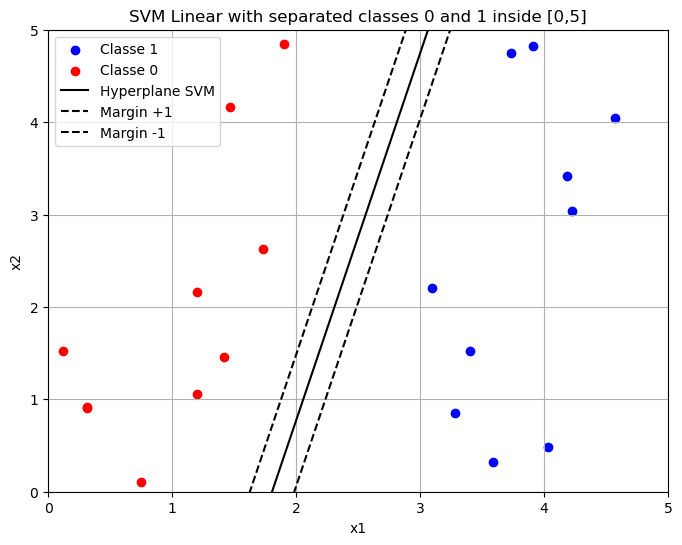

In [28]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.svm import SVC

# --------------------------
# 1. Génération de données 2D entre 0 et 5, séparées
# --------------------------
np.random.seed(42)

# Classe 0 : zone gauche (x entre 0 et 2)
X_class0 = np.column_stack((
    np.random.uniform(0, 2, 10),
    np.random.uniform(0, 5, 10)
))
y_class0 = np.zeros(10)  # <-- class 0

# Classe 1 : zone droite (x entre 3 et 5)
X_class1 = np.column_stack((
    np.random.uniform(3, 5, 10),
    np.random.uniform(0, 5, 10)
))
y_class1 = np.ones(10)  # <-- class 1

# Données finales
X = np.vstack((X_class1, X_class0))
y = np.hstack((y_class1, y_class0))

# --------------------------
# 2. Entraînement SVM linéaire
# --------------------------
svm_model = SVC(kernel='linear', C=1.0)
svm_model.fit(X, y)

# Poids et intercept
w = svm_model.coef_[0]
b = svm_model.intercept_[0]
print("Poids w:", w)
print("Intercept b:", b)

# --------------------------
# 3. Tracé de l'hyperplan et des marges
# --------------------------
xx = np.linspace(0, 5, 200)

# Hyperplan
yy_hyperplane = -(w[0] * xx + b) / w[1]

# Marges
margin = 1 / np.linalg.norm(w)
yy_margin_pos = yy_hyperplane + margin
yy_margin_neg = yy_hyperplane - margin

# --------------------------
# 4. Tracé
# --------------------------
plt.figure(figsize=(8,6))
plt.scatter(X_class1[:,0], X_class1[:,1], color='blue', label='Classe 1')
plt.scatter(X_class0[:,0], X_class0[:,1], color='red', label='Classe 0')
plt.plot(xx, yy_hyperplane, 'k-', label='Hyperplane SVM')
plt.plot(xx, yy_margin_pos, 'k--', label='Margin +1')
plt.plot(xx, yy_margin_neg, 'k--', label='Margin -1')
plt.xlim(0, 5)
plt.ylim(0, 5)
plt.xlabel('x1')
plt.ylabel('x2')
plt.title('SVM Linear with separated classes 0 and 1 inside [0,5]')
plt.legend()
plt.grid(True)
plt.show()


Weights w: [0.43438919 0.41628964]
Intercept b: -2.1457015411661633


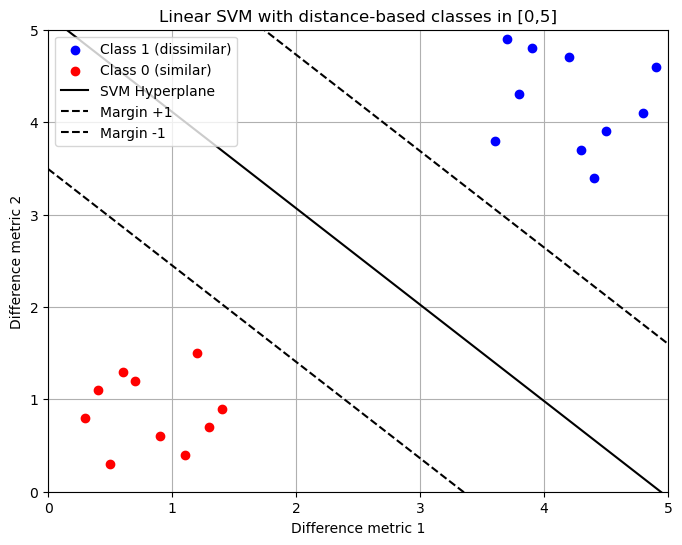

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.svm import SVC

# --------------------------
# 1. Custom 2D distance-based data (axes in [0,5])
# --------------------------

# Class 0: similar items (distances small, near the origin)
X_class0 = np.array([
    [0.3, 0.8],
    [1.1, 0.4],
    [0.7, 1.2],
    [1.4, 0.9],
    [0.5, 0.3],
    [1.2, 1.5],
    [0.9, 0.6],
    [0.4, 1.1],
    [1.3, 0.7],
    [0.6, 1.3]
])
y_class0 = np.zeros(10)

# Class 1: dissimilar items (distances large, towards upper-right)
X_class1 = np.array([
    [3.8, 4.3],
    [4.5, 3.9],
    [4.2, 4.7],
    [3.6, 3.8],
    [4.9, 4.6],
    [3.7, 4.9],
    [4.4, 3.4],
    [4.8, 4.1],
    [3.9, 4.8],
    [4.3, 3.7]
])
y_class1 = np.ones(10)

# Final dataset
X = np.vstack((X_class1, X_class0))
y = np.hstack((y_class1, y_class0))

# --------------------------
# 2. Train linear SVM
# --------------------------
svm_model = SVC(kernel='linear', C=1.0)
svm_model.fit(X, y)

# Extract weights and bias
w = svm_model.coef_[0]
b = svm_model.intercept_[0]
print("Weights w:", w)
print("Intercept b:", b)

# --------------------------
# 3. Compute hyperplane and margins
# --------------------------
xx = np.linspace(0, 5, 200)

yy_hyperplane = -(w[0] * xx + b) / w[1]

margin = 1 / np.linalg.norm(w)
yy_margin_pos = yy_hyperplane + margin
yy_margin_neg = yy_hyperplane - margin

# --------------------------
# 4. Plot
# --------------------------
plt.figure(figsize=(8,6))

plt.scatter(X_class1[:,0], X_class1[:,1], color='blue', label='Class 1 (dissimilar)')
plt.scatter(X_class0[:,0], X_class0[:,1], color='red', label='Class 0 (similar)')

plt.plot(xx, yy_hyperplane, 'k-', label='SVM Hyperplane')
plt.plot(xx, yy_margin_pos, 'k--', label='Margin +1')
plt.plot(xx, yy_margin_neg, 'k--', label='Margin -1')

plt.xlim(0, 5)
plt.ylim(0, 5)
plt.xlabel('Difference metric 1')
plt.ylabel('Difference metric 2')
plt.title('Linear SVM with distance-based classes in [0,5]')
plt.legend(loc='upper left')
plt.grid(True)
plt.show()


In [ ]:
x_point = np.array([5, 0])
decision_value = np.dot(w, x_point) + b

print("Valeur f(x) =", decision_value)

Valeur f(x) = -4.177493424286153


In [12]:
import pandas as pd
import numpy as np
import plotly.graph_objects as go

# Sample DataFrame with 3 objectives (to MINIMIZE)
df = pd.DataFrame({
    "obj1": [1, 2, 3, 4, 5, 3, 6],
    "obj2": [5, 4, 3, 2, 1, 6, 0.5],
    "obj3": [8, 7, 5, 4, 2, 9, 1]
})

# -----------------------------
# 1. Pareto Front Function
# -----------------------------
def pareto_front(points):
    points = np.asarray(points)
    n = points.shape[0]
    is_pareto = np.ones(n, dtype=bool)

    for i in range(n):
        if is_pareto[i]:
            dominates = np.all(points <= points[i], axis=1) & np.any(points < points[i], axis=1)
            is_pareto[i] = not np.any(dominates)
    return is_pareto

mask = pareto_front(df[["obj1", "obj2", "obj3"]])
pareto_df = df[mask]

# Sort Pareto points to create a clean line (choose any objective)
pareto_sorted = pareto_df.sort_values("obj1")

# -----------------------------
# 2. Plotly Interactive 3D Plot + Line
# -----------------------------

fig = go.Figure()

# All points
fig.add_trace(go.Scatter3d(
    x=df["obj1"], y=df["obj2"], z=df["obj3"],
    mode="markers",
    marker=dict(size=6),
    name="All Points"
))

# Pareto front points
fig.add_trace(go.Scatter3d(
    x=pareto_df["obj1"], y=pareto_df["obj2"], z=pareto_df["obj3"],
    mode="markers",
    marker=dict(size=9, color='red', symbol='circle-open', line=dict(width=3)),
    name="Pareto Front"
))

# 🔥 Connecting line for Pareto front
fig.add_trace(go.Scatter3d(
    x=pareto_sorted["obj1"],
    y=pareto_sorted["obj2"],
    z=pareto_sorted["obj3"],
    mode="lines",
    line=dict(width=4, color="red"),
    name="Pareto Front Line"
))

fig.update_layout(
    title="3D Pareto Front with Line (Plotly)",
    scene=dict(
        xaxis_title="Objective 1",
        yaxis_title="Objective 2",
        zaxis_title="Objective 3",
    ),
    width=800,
    height=600
)

fig.show()


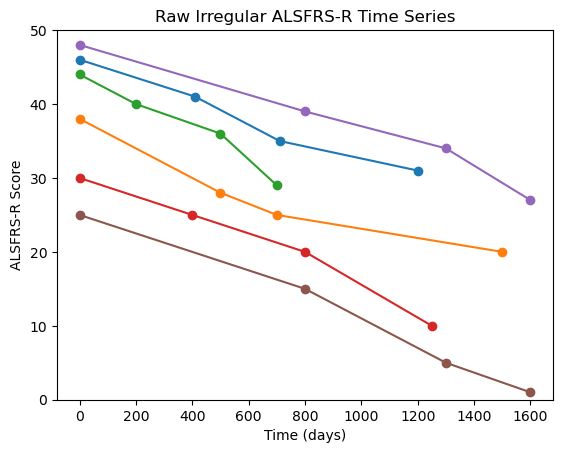

In [ ]:
import matplotlib.pyplot as plt

# 5 raw irregular ALSFRS-R temporal sequences
# Format: (time_in_days, ALSFRS-R score)

sequence_1 = [
    (0, 46),
    (410, 41),
    (710, 35),
    (1200, 31),
]

sequence_2 = [
    (0, 38),
    (500, 28),
    (700, 25),
    (1500, 20)
]

sequence_3 = [
    (0, 44),
    (200, 40),
    (500, 36),
    (700, 29),
]

sequence_4 = [
    (0, 30),
    (400, 25),
    (800, 20),
    (1250, 10),
]

sequence_5 = [
    (0, 48),
    (800, 39),
    (1300, 34),
    (1600, 27),
]

sequence_6 = [
    (0, 25),
    (800, 15),
    (1300, 5),
    (1600, 1),
]

sequences = [
    sequence_1,
    sequence_2,
    sequence_3,
    sequence_4,
    sequence_5,
    sequence_6
]

# Plot all sequences on the same figure
plt.figure()

for i, seq in enumerate(sequences, 1):
    times = [point[0] for point in seq]
    scores = [point[1] for point in seq]
    plt.plot(times, scores, marker='o', label=f"Patient {i}")

plt.xlabel("Time (days)")
plt.ylabel("ALSFRS-R Score")
plt.title("Raw Irregular ALSFRS-R Time Series")
plt.ylim(0, 50)
plt.show()

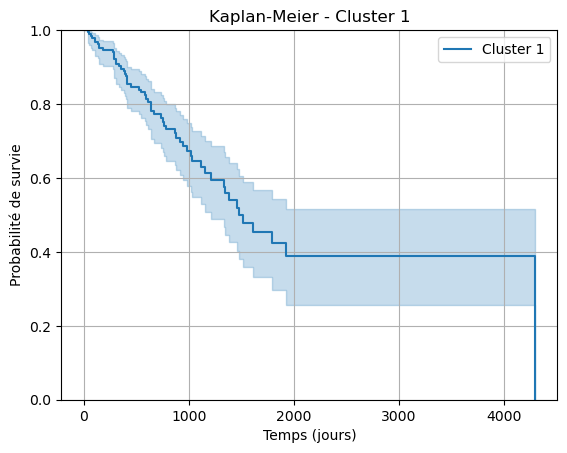

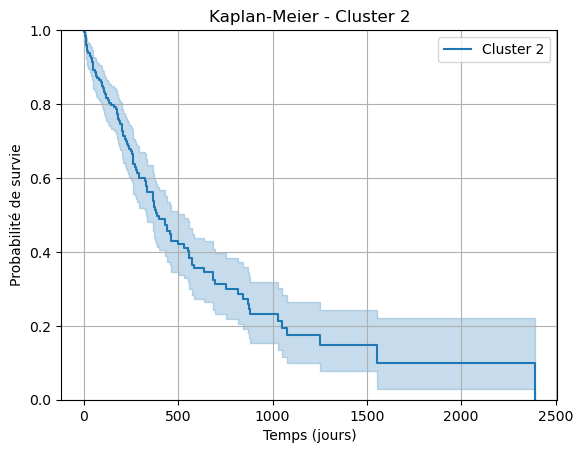

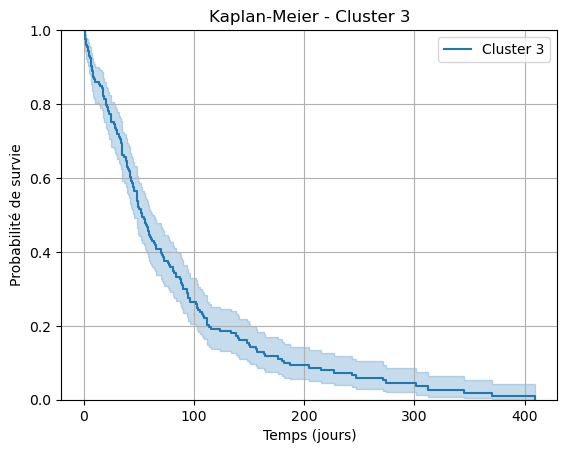

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from lifelines import KaplanMeierFitter

np.random.seed(123)

n = 200
kmf = KaplanMeierFitter()

# ===============================
# Groupe A : Survie très longue
# ===============================
durations_A = np.random.exponential(scale=800, size=n)  # temps très longs
event_A = np.random.binomial(1, 0.3, size=n)  # peu d'événements

plt.figure()
kmf.fit(durations_A, event_A, label="Cluster 1")
kmf.plot_survival_function()
plt.xlabel("Temps (jours)")
plt.ylabel("Probabilité de survie")
plt.title("Kaplan-Meier - Cluster 1")
plt.ylim(0, 1)
plt.grid(True)
plt.show()


# ===============================
# Groupe B : Survie intermédiaire
# ===============================
durations_B = np.random.exponential(scale=350, size=n)
event_B = np.random.binomial(1, 0.6, size=n)

plt.figure()
kmf.fit(durations_B, event_B, label="Cluster 2")
kmf.plot_survival_function()
plt.xlabel("Temps (jours)")
plt.ylabel("Probabilité de survie")
plt.title("Kaplan-Meier - Cluster 2")
plt.ylim(0, 1)
plt.grid(True)
plt.show()


# ===============================
# Groupe C : Survie très courte
# ===============================
durations_C = np.random.exponential(scale=80, size=n)  # événements précoces
event_C = np.random.binomial(1, 0.9, size=n)  # beaucoup d'événements

plt.figure()
kmf.fit(durations_C, event_C, label="Cluster 3")
kmf.plot_survival_function()
plt.xlabel("Temps (jours)")
plt.ylabel("Probabilité de survie")
plt.title("Kaplan-Meier - Cluster 3")
plt.ylim(0, 1)
plt.grid(True)
plt.show()

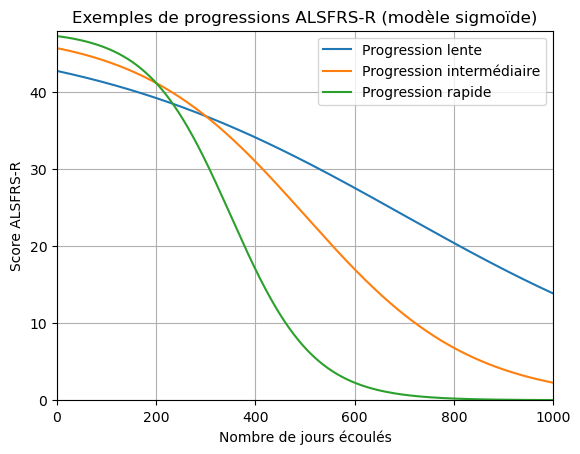

In [5]:
import numpy as np
import matplotlib.pyplot as plt

# Axe des jours (par exemple sur 3 ans)
jours = np.linspace(0, 1000, 1000)

# Fonction sigmoïde adaptée au score ALSFRS-R (entre 0 et 48)
def sigmoid(t, L, k, t0):
    return L / (1 + np.exp(k * (t - t0)))

L = 48  # Score maximum ALSFRS-R

# Trois progressions différentes
sig_lente = sigmoid(jours, L, 0.003, 700)      # progression lente
sig_intermediaire = sigmoid(jours, L, 0.006, 500)  # progression moyenne
sig_rapide = sigmoid(jours, L, 0.012, 350)     # progression rapide

# Tracé
plt.figure()
plt.plot(jours, sig_lente, label="Progression lente")
plt.plot(jours, sig_intermediaire, label="Progression intermédiaire")
plt.plot(jours, sig_rapide, label="Progression rapide")

# Mise en forme
plt.xlabel("Nombre de jours écoulés")
plt.ylabel("Score ALSFRS-R")
plt.ylim(0, 48)
plt.xlim(0, 1000)
plt.legend()
plt.title("Exemples de progressions ALSFRS-R (modèle sigmoïde)")
plt.grid(True)

plt.show()

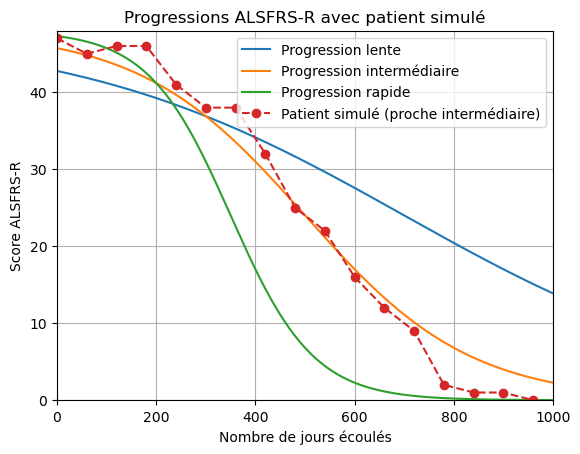

In [13]:
import numpy as np
import matplotlib.pyplot as plt

# Axe des jours (3 ans)
jours = np.linspace(0, 1000, 1000)

# Fonction sigmoïde (déclin ALSFRS-R)
def sigmoid(t, L, k, t0):
    return L / (1 + np.exp(k * (t - t0)))

L = 48  # Score maximum ALSFRS-R

# Trois progressions différentes
sig_lente = sigmoid(jours, L, 0.003, 700)
sig_intermediaire = sigmoid(jours, L, 0.006, 500)
sig_rapide = sigmoid(jours, L, 0.012, 350)

# -----------------------------
# Simulation d'un patient
# -----------------------------

# RDV tous les 60 jours
jours_patient = np.arange(0, 1000, 60)

# Base proche de la progression intermédiaire
score_base = sigmoid(jours_patient, L, 0.006, 500)

np.random.seed(42)

# Variabilité plus marquée
bruit_gaussien = np.random.normal(0, 2.0, len(score_base))

# Petite variation non linéaire pour s'éloigner légèrement de la sigmoïde
variation_systematique = 1.5 * np.sin(jours_patient / 180)

score_patient = score_base + bruit_gaussien + variation_systematique

# Bornage entre 0 et 48 et arrondi entier
score_patient = np.clip(np.round(score_patient), 0, 48)

# -----------------------------
# Tracé
# -----------------------------
plt.figure()

plt.plot(jours, sig_lente, label="Progression lente")
plt.plot(jours, sig_intermediaire, label="Progression intermédiaire")
plt.plot(jours, sig_rapide, label="Progression rapide")

# Ligne patient en pointillé
plt.plot(jours_patient, score_patient, linestyle="--",
         marker="o", label="Patient simulé (proche intermédiaire)")

plt.xlabel("Nombre de jours écoulés")
plt.ylabel("Score ALSFRS-R")
plt.ylim(0, 48)
plt.xlim(0, 1000)
plt.legend()
plt.title("Progressions ALSFRS-R avec patient simulé")
plt.grid(True)

plt.show()

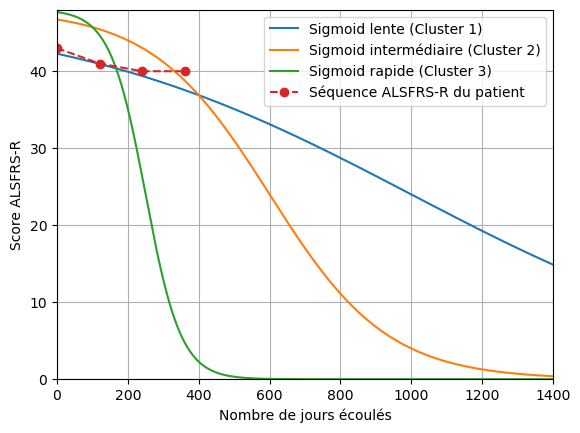

In [30]:
import numpy as np
import matplotlib.pyplot as plt

# Axe temps
jours = np.linspace(0, 1400, 1400)

def sigmoid(t, L, k, t0):
    return L / (1 + np.exp(k * (t - t0)))

L = 48

# Sigmoïdes
sig_lente = sigmoid(jours, L, 0.002, 1000)
sig_intermediaire = sigmoid(jours, L, 0.006, 600)
sig_rapide = sigmoid(jours, L, 0.02, 250)

# -----------------------------
# Patient
# -----------------------------

jours_patient = np.arange(0, 1400, 120)

score_lent = sigmoid(jours_patient, L, 0.002, 1000)
score_inter = sigmoid(jours_patient, L, 0.006, 600)

t_transition = 700
poids = 1 / (1 + np.exp(-(jours_patient - t_transition)/80))

score_patient = (1 - poids) * score_lent + poids * score_inter

np.random.seed(42)
score_patient += np.random.normal(0, 1.5, len(score_patient))
score_patient = np.clip(np.round(score_patient), 0, 48)

# -----------------------------
# SEUIL TEMPOREL
# -----------------------------

seuil_temps = 400  # 🔁 à modifier

masque = jours_patient <= seuil_temps

jours_affiches = jours_patient[masque]
scores_affiches = score_patient[masque]

# -----------------------------
# Plot
# -----------------------------

plt.figure()

plt.plot(jours, sig_lente, label="Sigmoid lente (Cluster 1)")
plt.plot(jours, sig_intermediaire, label="Sigmoid intermédiaire (Cluster 2)")
plt.plot(jours, sig_rapide, label="Sigmoid rapide (Cluster 3)")

plt.plot(jours_affiches, scores_affiches,
         linestyle="--", marker="o",
         label="Séquence ALSFRS-R du patient")

#plt.axvline(seuil_temps, linestyle=":", label="Seuil temporel")

plt.xlabel("Nombre de jours écoulés")
plt.ylabel("Score ALSFRS-R")
plt.ylim(0, 48)
plt.xlim(0, 1400)
plt.legend()
plt.grid(True)

plt.show()

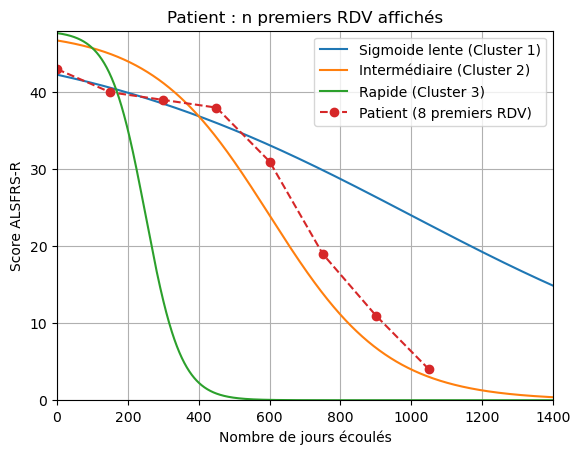

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Axe temps
jours = np.linspace(0, 1400, 1400)

def sigmoid(t, L, k, t0):
    return L / (1 + np.exp(k * (t - t0)))

L = 48

# Sigmoïdes
sig_lente = sigmoid(jours, L, 0.002, 1000)
sig_intermediaire = sigmoid(jours, L, 0.006, 600)
sig_rapide = sigmoid(jours, L, 0.02, 250)

# -----------------------------
# Patient
# -----------------------------

jours_patient = np.arange(0, 1400, 150)  # moins de RDV
score_lent = sigmoid(jours_patient, L, 0.002, 1000)
score_inter = sigmoid(jours_patient, L, 0.006, 600)

t_transition = 700
poids = 1 / (1 + np.exp(-(jours_patient - t_transition)/80))
score_patient = (1 - poids) * score_lent + poids * score_inter

np.random.seed(42)
score_patient += np.random.normal(0, 1.5, len(score_patient))
score_patient = np.clip(np.round(score_patient), 0, 48)

# -----------------------------
# Seuil : n premiers RDV
# -----------------------------

n_rdv = 8  # 🔁 Affiche uniquement les 5 premiers RDV

jours_affiches = jours_patient[:n_rdv]
scores_affiches = score_patient[:n_rdv]

# -----------------------------
# Plot
# -----------------------------

plt.figure()

plt.plot(jours, sig_lente, label="Sigmoide lente (Cluster 1)")
plt.plot(jours, sig_intermediaire, label="Intermédiaire (Cluster 2)")
plt.plot(jours, sig_rapide, label="Rapide (Cluster 3)")

plt.plot(jours_affiches, scores_affiches,
         linestyle="--", marker="o",
         label=f"Patient ({n_rdv} premiers RDV)")

plt.xlabel("Nombre de jours écoulés")
plt.ylabel("Score ALSFRS-R")
plt.ylim(0, 48)
plt.xlim(0, 1400)
plt.legend()
plt.grid(True)b
plt.title("Patient : n premiers RDV affichés")

plt.show()

sig_lente (Cluster 1): fitted params = b=68.34, k=0.0011, a=1349.6, c=-16.35
sig_intermediaire (Cluster 2): fitted params = b=47.08, k=0.0062, a=595.5, c=0.71
sig_rapide (Cluster 3): fitted params = b=46.15, k=0.0214, a=248.6, c=0.98


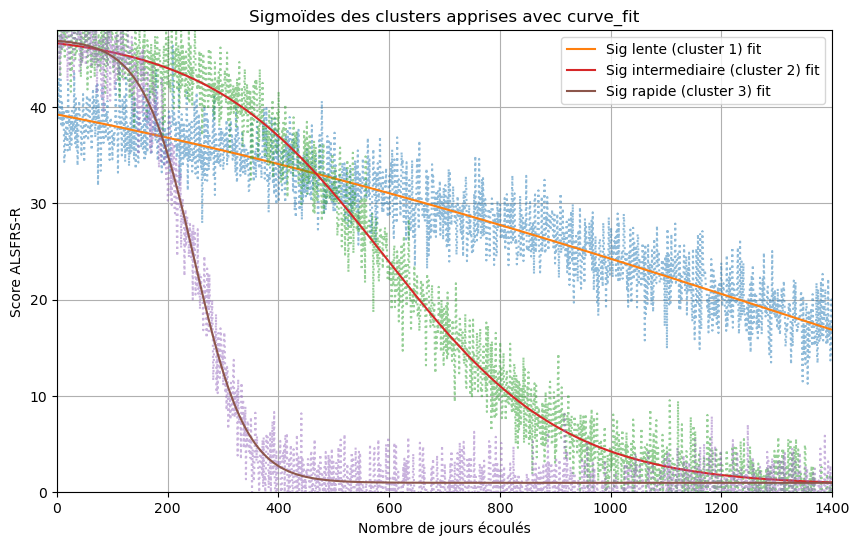

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

# Axe temps
jours = np.linspace(0, 1400, 1400)

# Nouvelle fonction sigmoïde
def sigmoid(x, b, k, a, c):
    return b / (1 + np.exp(k * (x - a))) + c

# True cluster parameters (used to generate synthetic cluster data)
true_params = {
    "sig_lente (Cluster 1)": (48, 0.0015, 1000, 0),
    "sig_intermediaire (Cluster 2)": (48, 0.006, 600, 0),
    "sig_rapide (Cluster 3)": (48, 0.02, 250, 0)
}

np.random.seed(42)
sigma_sigmoid = 2.5  # noise for simulated cluster data

plt.figure(figsize=(10,6))

# Learn parameters with curve_fit
for label, (b_true, k_true, a_true, c_true) in true_params.items():
    # Generate noisy cluster data
    sig_noisy = sigmoid(jours, b_true, k_true, a_true, c_true)
    sig_noisy += np.random.normal(0, sigma_sigmoid, len(sig_noisy))
    sig_noisy = np.clip(sig_noisy, 0, b_true + c_true)

    # Fit sigmoid to noisy data
    p0 = [b_true, k_true, a_true, c_true]  # initial guess
    params_fit, _ = curve_fit(sigmoid, jours, sig_noisy, p0=p0)
    b_fit, k_fit, a_fit, c_fit = params_fit

    # Predict fitted sigmoid
    sig_fitted = sigmoid(jours, *params_fit)

    # Plot
    plt.plot(jours, sig_noisy, linestyle=':', alpha=0.5)
    plt.plot(jours, sig_fitted, label=f"{label.replace('_',' ').capitalize()} fit")
    print(f"{label}: fitted params = b={b_fit:.2f}, k={k_fit:.4f}, a={a_fit:.1f}, c={c_fit:.2f}")

plt.xlabel("Nombre de jours écoulés")
plt.ylabel("Score ALSFRS-R")
plt.ylim(0, 48)
plt.xlim(0, 1400)
plt.legend()
plt.grid(True)
plt.title("Sigmoïdes des clusters apprises avec curve_fit")
plt.show()

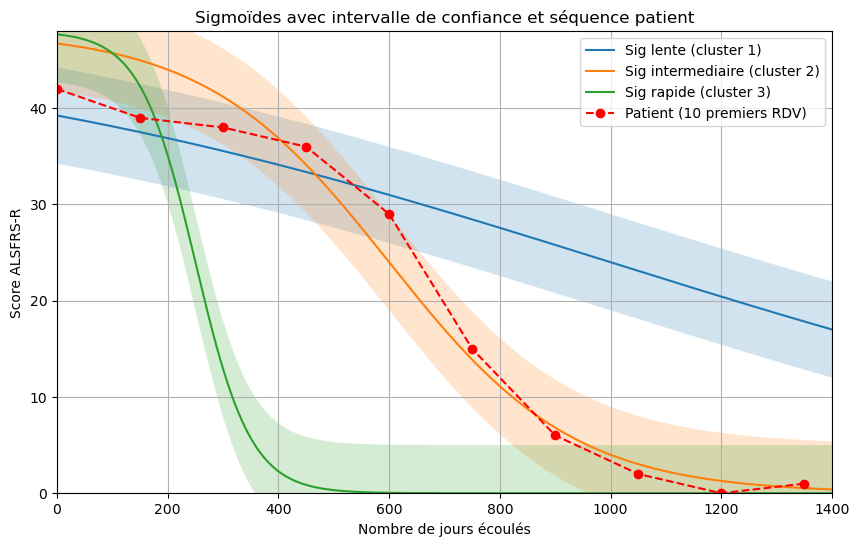

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# Axe temps
jours = np.linspace(0, 1400, 1400)

def sigmoid(t, L, k, t0):
    return L / (1 + np.exp(k * (t - t0)))
    #return (b) / (1 + np.exp((k * (x - a)))) + c

L = 48

# -----------------------------
# Sigmoïdes des clusters
# -----------------------------
params = {
    "sig_lente (Cluster 1)": (0.0015, 1000),
    "sig_intermediaire (Cluster 2)": (0.006, 600),
    "sig_rapide (Cluster 3)": (0.02, 250)
}

np.random.seed(42)
sigma_sigmoid = 2.5  # incertitude sur les valeurs des sigmoïdes

plt.figure(figsize=(10,6))

for label, (k, t0) in params.items():
    sig = sigmoid(jours, L, k, t0)
    
    # Intervalle de confiance ±2*sigma
    ic_sup = np.clip(sig + 2*sigma_sigmoid, 0, L)
    ic_inf = np.clip(sig - 2*sigma_sigmoid, 0, L)
    
    plt.plot(jours, sig, label=label.replace("_", " ").capitalize())
    plt.fill_between(jours, ic_inf, ic_sup, alpha=0.2)

# -----------------------------
# Patient
# -----------------------------
jours_patient = np.arange(0, 1400, 150)
score_lent = sigmoid(jours_patient, L, 0.002, 900)
score_inter = sigmoid(jours_patient, L, 0.01, 600)

t_transition = 700
poids = 1 / (1 + np.exp(-(jours_patient - t_transition)/80))
score_patient = (1 - poids) * score_lent + poids * score_inter

sigma_patient = 1
score_patient_noisy = score_patient + np.random.normal(0, sigma_patient, len(score_patient))
score_patient_noisy = np.clip(np.round(score_patient_noisy), 0, L)

# n premiers RDV
n_rdv = 10
jours_affiches = jours_patient[:n_rdv]
scores_affiches = score_patient_noisy[:n_rdv]

plt.plot(jours_affiches, scores_affiches,
         linestyle="--", marker="o",
         color="red",
         label=f"Patient ({n_rdv} premiers RDV)")

plt.xlabel("Nombre de jours écoulés")
plt.ylabel("Score ALSFRS-R")
plt.ylim(0, 48)
plt.xlim(0, 1400)
plt.legend()
plt.grid(True)
plt.title("Sigmoïdes avec intervalle de confiance et séquence patient")
plt.show()

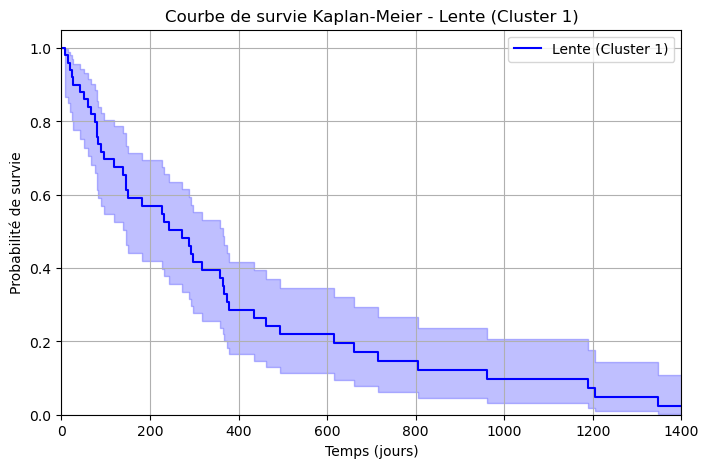

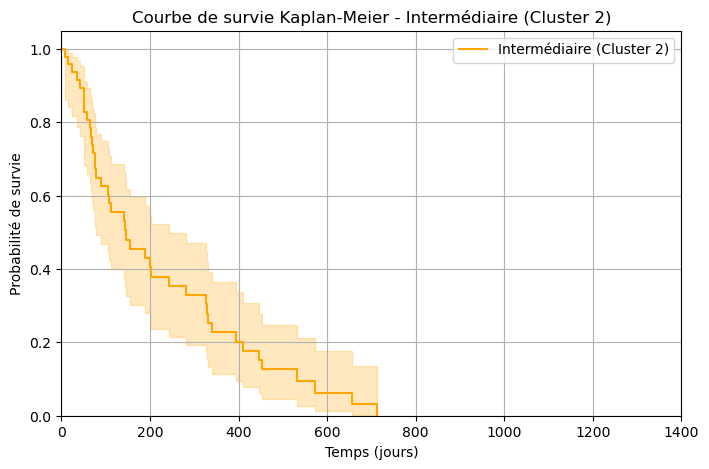

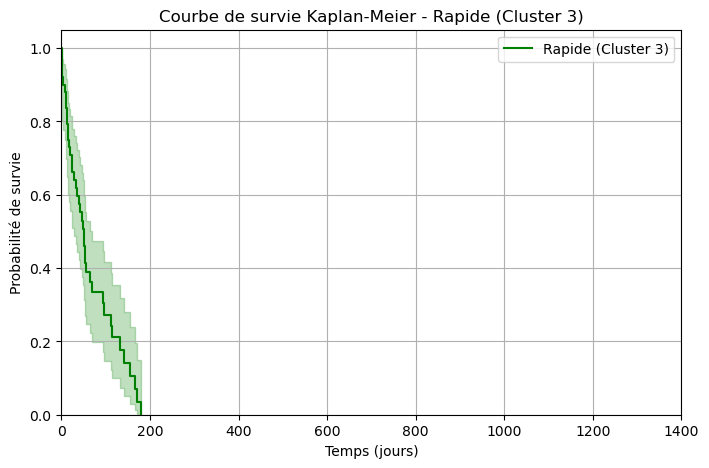

In [44]:
import numpy as np
import matplotlib.pyplot as plt
from lifelines import KaplanMeierFitter

np.random.seed(42)
n_patients = 50
Tmax = 1400  # axe X figé

# Définir les clusters avec échelle de survie et couleur
clusters = {
    "Lente (Cluster 1)": {"scale": 400, "prob_event": 0.9, "color": "blue"},
    "Intermédiaire (Cluster 2)": {"scale": 200, "prob_event": 0.85, "color": "orange"},
    "Rapide (Cluster 3)": {"scale": 50, "prob_event": 0.8, "color": "green"}
}

for label, info in clusters.items():
    # Simuler les temps de survie exponentiels
    temps = np.random.exponential(scale=info["scale"], size=n_patients)
    event_observed = np.random.binomial(1, info["prob_event"], size=n_patients)
    
    kmf = KaplanMeierFitter()
    kmf.fit(durations=temps, event_observed=event_observed, label=label)
    
    plt.figure(figsize=(8,5))
    kmf.plot_survival_function(ci_show=True, color=info["color"])
    plt.title(f"Courbe de survie Kaplan-Meier - {label}")
    plt.xlabel("Temps (jours)")
    plt.ylabel("Probabilité de survie")
    
    plt.xlim(0, Tmax)
    plt.ylim(0, 1.05)
    plt.grid(True)
    plt.show()

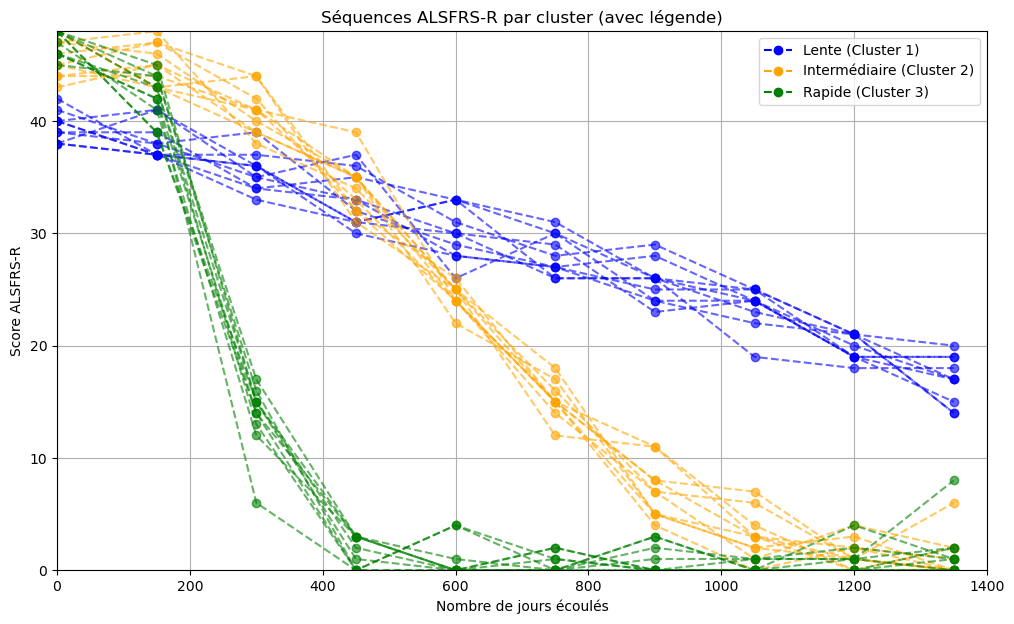

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Axe temps
jours_patient = np.arange(0, 1400, 150)  # RDV tous les 150 jours
L = 48

def sigmoid(t, L, k, t0):
    return L / (1 + np.exp(k * (t - t0)))

# -----------------------------
# Paramètres des clusters
# -----------------------------
params = {
    "Lente (Cluster 1)": {"k": 0.0015, "t0": 1000, "color": "blue"},
    "Intermédiaire (Cluster 2)": {"k": 0.006, "t0": 600, "color": "orange"},
    "Rapide (Cluster 3)": {"k": 0.02, "t0": 250, "color": "green"}
}

np.random.seed(42)
n_patients = 10      # nombre de patients par cluster
sigma_patient = 2    # bruit pour variabilité patient

plt.figure(figsize=(12,7))

for label, info in params.items():
    for i in range(n_patients):
        # Générer le score patient autour de la sigmoïde
        score_patient = sigmoid(jours_patient, L, info["k"], info["t0"])
        score_patient_noisy = np.clip(np.round(score_patient + np.random.normal(0, sigma_patient, len(jours_patient))), 0, L)
        
        # Tracer la séquence patient
        plt.plot(jours_patient, score_patient_noisy,
                 linestyle="--", marker="o",
                 color=info["color"], alpha=0.6)
    
    # Ajouter un "dummy line" pour la légende du cluster
    plt.plot([], [], color=info["color"], linestyle="--", marker="o", label=label)

plt.xlabel("Nombre de jours écoulés")
plt.ylabel("Score ALSFRS-R")
plt.ylim(0, 48)
plt.xlim(0, 1400)
plt.grid(True)
plt.title("Séquences ALSFRS-R par cluster (avec légende)")
plt.legend(loc="upper right", fontsize=10)
plt.show()

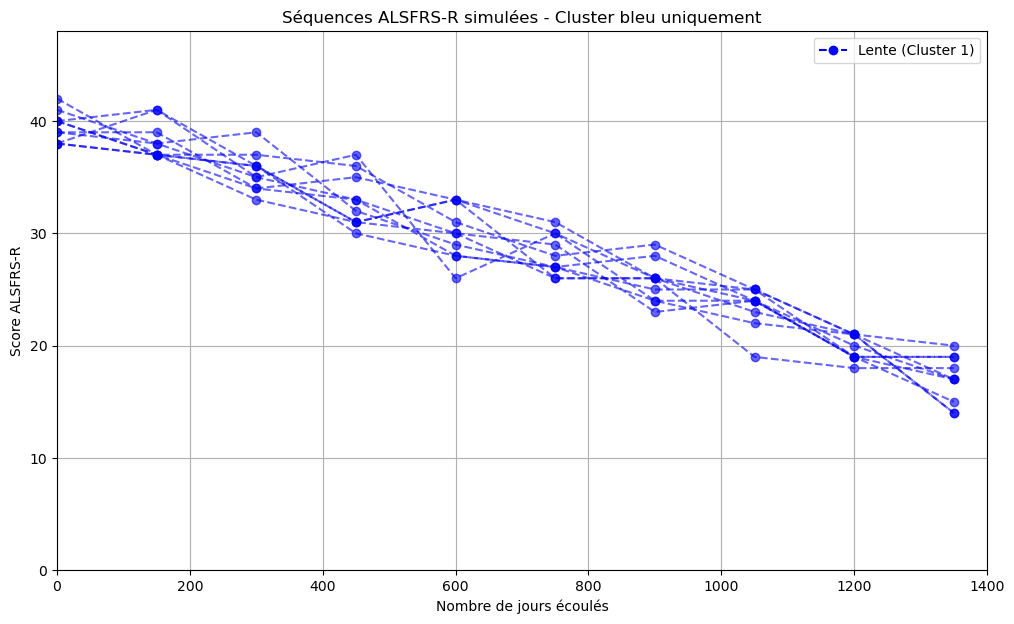

In [46]:
import numpy as np
import matplotlib.pyplot as plt

# Axe temps
jours_patient = np.arange(0, 1400, 150)  # RDV tous les 150 jours
L = 48

def sigmoid(t, L, k, t0):
    return L / (1 + np.exp(k * (t - t0)))

# -----------------------------
# Paramètres du cluster bleu (lent)
# -----------------------------
cluster_bleu = {"k": 0.0015, "t0": 1000, "color": "blue", "label": "Lente (Cluster 1)"}

np.random.seed(42)
n_patients = 10      # nombre de patients
sigma_patient = 2    # bruit pour variabilité patient

plt.figure(figsize=(12,7))

for i in range(n_patients):
    # Générer le score patient autour de la sigmoïde
    score_patient = sigmoid(jours_patient, L, cluster_bleu["k"], cluster_bleu["t0"])
    score_patient_noisy = np.clip(np.round(score_patient + np.random.normal(0, sigma_patient, len(jours_patient))), 0, L)
    
    # Tracer la séquence patient
    plt.plot(jours_patient, score_patient_noisy,
             linestyle="--", marker="o",
             color=cluster_bleu["color"], alpha=0.6)

# Légende pour le cluster
plt.plot([], [], color=cluster_bleu["color"], linestyle="--", marker="o", label=cluster_bleu["label"])

plt.xlabel("Nombre de jours écoulés")
plt.ylabel("Score ALSFRS-R")
plt.ylim(0, 48)
plt.xlim(0, 1400)
plt.grid(True)
plt.title("Séquences ALSFRS-R simulées - Cluster bleu uniquement")
plt.legend(loc="upper right", fontsize=10)
plt.show()

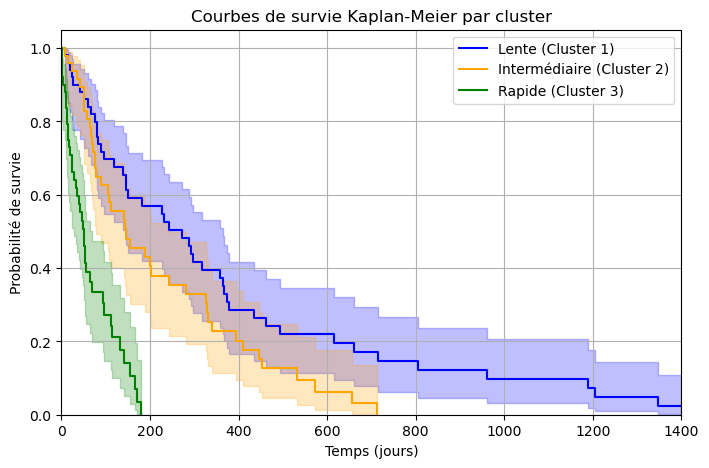

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from lifelines import KaplanMeierFitter

np.random.seed(42)
n_patients = 50
Tmax = 1400  # axe X figé

# Définir les clusters avec échelle de survie et couleur
clusters = {
    "Lente (Cluster 1)": {"scale": 400, "prob_event": 0.9, "color": "blue"},
    "Intermédiaire (Cluster 2)": {"scale": 200, "prob_event": 0.85, "color": "orange"},
    "Rapide (Cluster 3)": {"scale": 50, "prob_event": 0.8, "color": "green"}
}

plt.figure(figsize=(8,5))

for label, info in clusters.items():
    # Simuler les temps de survie exponentiels
    temps = np.random.exponential(scale=info["scale"], size=n_patients)
    event_observed = np.random.binomial(1, info["prob_event"], size=n_patients)
    
    kmf = KaplanMeierFitter()
    kmf.fit(durations=temps, event_observed=event_observed, label=label)
    
    kmf.plot_survival_function(ci_show=True, color=info["color"])

plt.title("Courbes de survie Kaplan-Meier par cluster")
plt.xlabel("Temps (jours)")
plt.ylabel("Probabilité de survie")
plt.xlim(0, Tmax)
plt.ylim(0, 1.05)
plt.grid(True)
plt.legend()
plt.show()

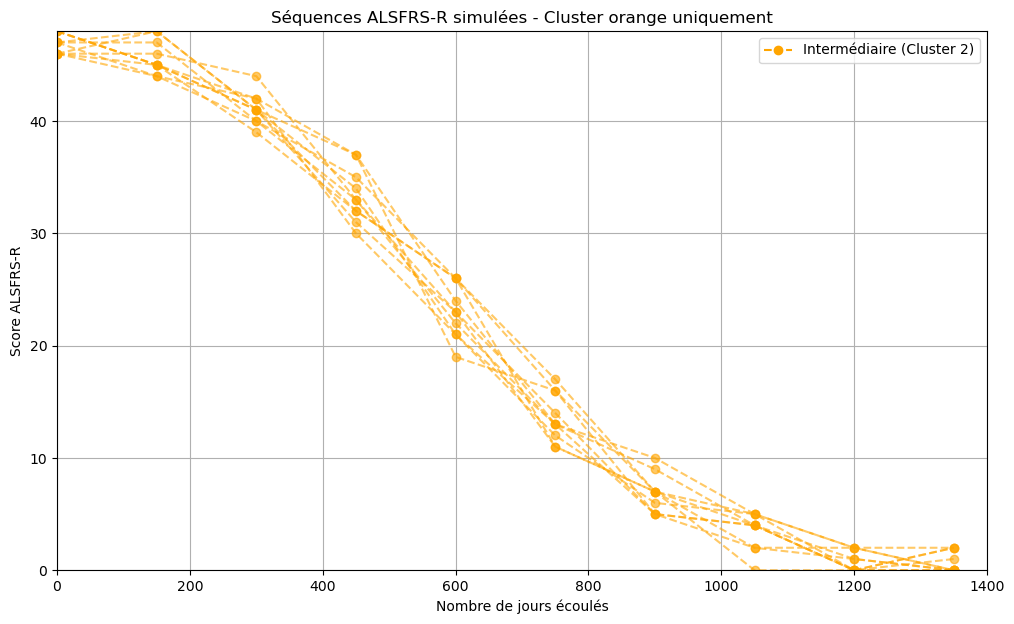

In [47]:
import numpy as np
import matplotlib.pyplot as plt

# Axe temps
jours_patient = np.arange(0, 1400, 150)  # RDV tous les 150 jours
L = 48

def sigmoid(t, L, k, t0):
    return L / (1 + np.exp(k * (t - t0)))

# -----------------------------
# Paramètres du cluster orange (intermédiaire)
# -----------------------------
cluster_orange = {"k": 0.006, "t0": 600, "color": "orange", "label": "Intermédiaire (Cluster 2)"}

np.random.seed(42)
n_patients = 10      # nombre de patients
sigma_patient = 2    # bruit pour variabilité patient

plt.figure(figsize=(12,7))

for i in range(n_patients):
    # Générer le score patient autour de la sigmoïde
    score_patient = sigmoid(jours_patient, L, cluster_orange["k"], cluster_orange["t0"])
    score_patient_noisy = np.clip(np.round(score_patient + np.random.normal(0, sigma_patient, len(jours_patient))), 0, L)
    
    # Tracer la séquence patient
    plt.plot(jours_patient, score_patient_noisy,
             linestyle="--", marker="o",
             color=cluster_orange["color"], alpha=0.6)

# Légende pour le cluster
plt.plot([], [], color=cluster_orange["color"], linestyle="--", marker="o", label=cluster_orange["label"])

plt.xlabel("Nombre de jours écoulés")
plt.ylabel("Score ALSFRS-R")
plt.ylim(0, 48)
plt.xlim(0, 1400)
plt.grid(True)
plt.title("Séquences ALSFRS-R simulées - Cluster orange uniquement")
plt.legend(loc="upper right", fontsize=10)
plt.show()

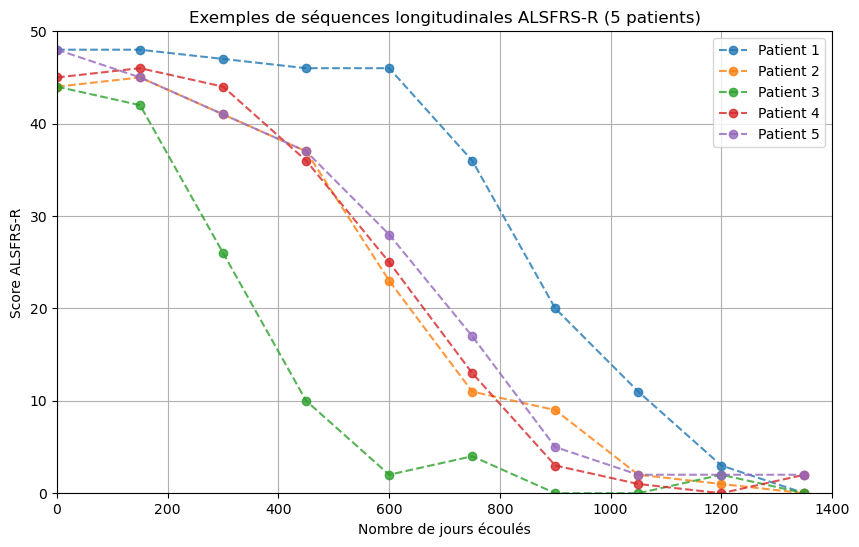

In [8]:
import numpy as np
import matplotlib.pyplot as plt

# Axe temps (consultations tous les 150 jours)
jours_patient = np.arange(0, 1400, 150)
L = 48  # Score ALSFRS-R max

def sigmoid(t, L, k, t0):
    return L / (1 + np.exp(k * (t - t0)))

np.random.seed(42)
n_patients = 5
sigma_patient = 2  # variabilité individuelle

plt.figure(figsize=(10,6))

for i in range(n_patients):
    # Paramètres légèrement différents pour chaque patient
    k_patient = np.random.uniform(0.003, 0.015)
    t0_patient = np.random.uniform(300, 900)
    
    score = sigmoid(jours_patient, L, k_patient, t0_patient)
    score_noisy = np.clip(
        np.round(score + np.random.normal(0, sigma_patient, len(jours_patient))),
        0, L
    )
    
    plt.plot(jours_patient, score_noisy,
             linestyle="--", marker="o",
             alpha=0.8,
             label=f"Patient {i+1}")

plt.xlabel("Nombre de jours écoulés")
plt.ylabel("Score ALSFRS-R")
plt.ylim(0, 50)
plt.xlim(0, 1400)
plt.grid(True)
plt.title("Exemples de séquences longitudinales ALSFRS-R (5 patients)")
plt.legend()
plt.show()

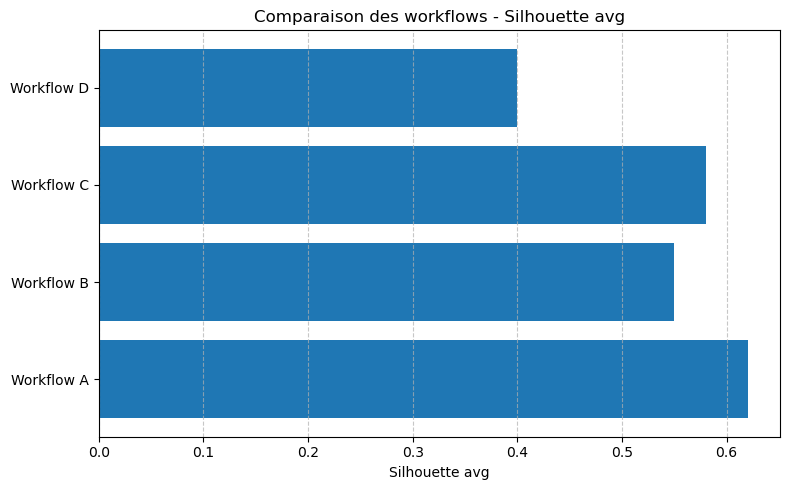

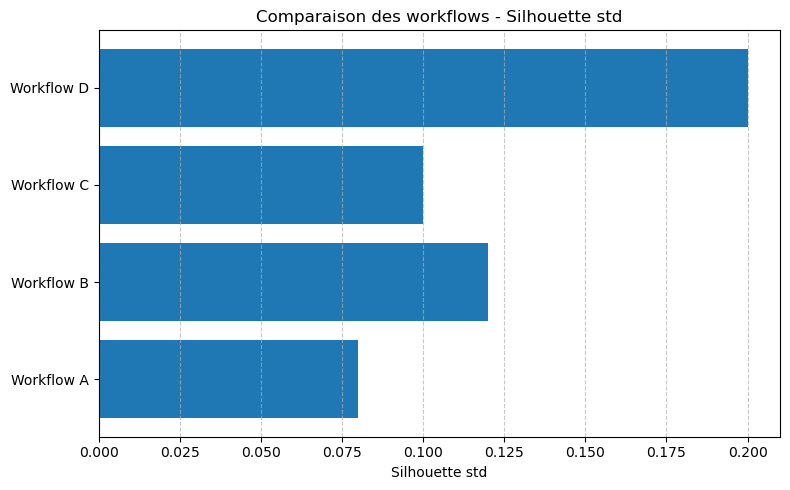

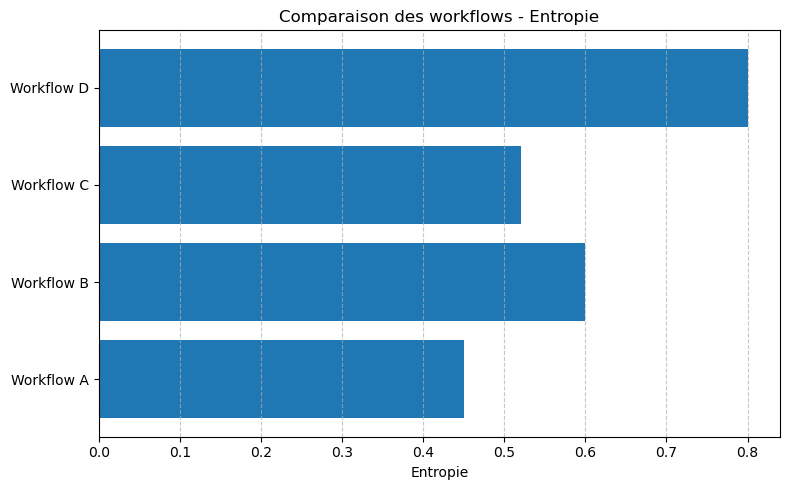

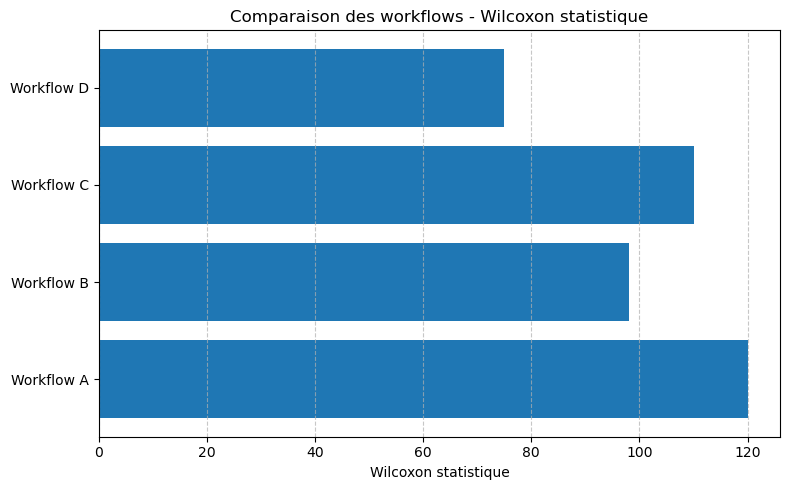

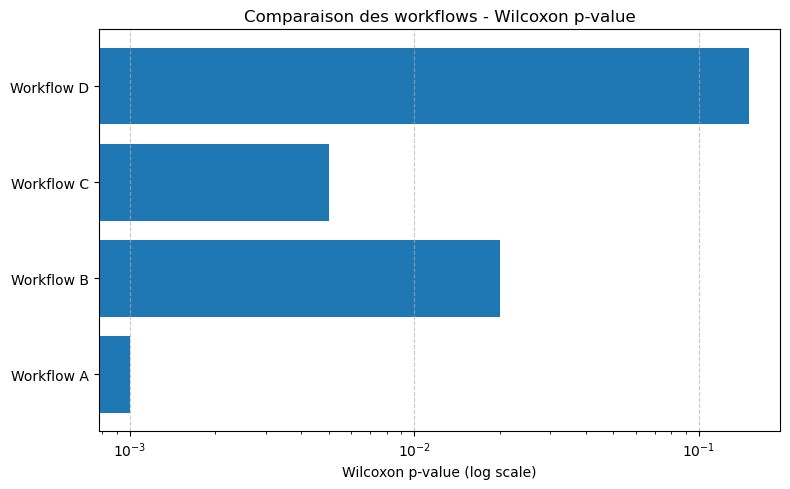

In [5]:
import numpy as np
import matplotlib.pyplot as plt

# -------------------------
# 1️⃣ Définition des workflows
# -------------------------
workflows = [
    "Workflow A",
    "Workflow B",
    "Workflow C",
    "Workflow D"
]

# -------------------------
# 2️⃣ Exemple de métriques simulées
# -------------------------
np.random.seed(42)

metrics = {
    "Silhouette avg": [0.62, 0.55, 0.58, 0.40],
    "Silhouette std": [0.08, 0.12, 0.10, 0.20],
    "Entropie": [0.45, 0.60, 0.52, 0.80],
    "Wilcoxon statistique": [120, 98, 110, 75],
    "Wilcoxon p-value": [0.001, 0.02, 0.005, 0.15]
}

# -------------------------
# 3️⃣ Fonction de plotting horizontal
# -------------------------
def plot_metric_horizontal(metric_name, values):
    plt.figure(figsize=(8, 5))
    
    y_pos = np.arange(len(workflows))
    
    plt.barh(y_pos, values)
    plt.yticks(y_pos, workflows)
    
    plt.title(f"Comparaison des workflows - {metric_name}")
    plt.xlabel(metric_name)
    plt.grid(axis="x", linestyle="--", alpha=0.7)

    # Cas particulier : p-value → échelle log
    if "p-value" in metric_name:
        plt.xscale("log")
        plt.xlabel("Wilcoxon p-value (log scale)")

    plt.tight_layout()
    plt.show()

# -------------------------
# 4️⃣ Génération des figures
# -------------------------
for metric_name, values in metrics.items():
    plot_metric_horizontal(metric_name, values)